

# Low-level LSL API

.. include:: ./../../links.inc


LSL is a library designed for streaming time series data across different platforms and
programming languages. The [core library](lsl lib_) is primarily written in C++, and
bindings are accessible for Python, C#, Java, MATLAB, and Unity, among others. You can
find a comprehensive list [here](lsl language bindings_).

MNE-LSL provides a reimplementation of the [python binding](lsl python_), known as
``pylsl``, within the ``mne_lsl.lsl`` module. It introduces additional functionalities
to simplify the low-level interaction with LSL streams. Moreover, it enhances the
detection of liblsl on your system and can retrieve a compatible version online if
necessary. The differences between ``pylsl`` and ``mne_lsl.lsl`` are detailed
`here<resources/pylsl:Differences with pylsl>`.


In [1]:
import time
import uuid

from mne_lsl.lsl import (
    StreamInfo, StreamInlet, StreamOutlet, local_clock, resolve_streams
)
from pylsl import resolve_stream
import mne
import os,pandas as pd
import numpy as np
import pathlib


import logging

# For interactive plots
from IPython import get_ipython
get_ipython().run_line_magic('matplotlib', 'qt')

# Define paths: 
current_path = pathlib.Path().absolute().parent  
recording_path = current_path / 'Recordings'


## Discover streams

At this point, the :class:`~mne_lsl.lsl.StreamOutlet` is available on the network. The
function :func:`~mne_lsl.lsl.resolve_streams` discovers all available streams on the
network. This operation is commonly named the stream resolution.

<div class="alert alert-info"><h4>Note</h4><p>The stream resolution can be restricted by providing the ``name``, ``stype``, and
    ``source_id`` arguments.</p></div>



In [2]:
streams = resolve_streams()

streams[:]

[< sInfo 'LiveAmpSN-101402-0868' >
   | Type: EEG
   | Sampling: 500.0 Hz
   | Number of channels: 67
   | Data type: <class 'numpy.float32'>
   | Source: LiveAmpSN-101402-0868,
 < sInfo 'Trigger' >
   | Type: Markers
   | Sampling: Irregular
   | Number of channels: 1
   | Data type: <class 'numpy.int32'>
   | Source: fNIRS_Trigger]

The resolution retrieves only the stream basic properties. The channel properties,
stored in the stream description in an XML element tree, are absent from a
:class:`~mne_lsl.lsl.StreamInfo` returned by the resolution function.



In [3]:
assert streams[0].get_channel_names() is None

## Connect to a Stream

To connect to a stream, a :class:`~mne_lsl.lsl.StreamInlet` object must be created
using the resolved :class:`~mne_lsl.lsl.StreamInfo`. Once the stream is opened with
:meth:`~mne_lsl.lsl.StreamInlet.open_stream`, the connection is established and
both the properties and data become available.



In [4]:
inlet = StreamInlet(streams[0])
inlet.open_stream()
sinfo = inlet.get_sinfo()  # retrieve stream information with all properties

In [5]:
sinfo

< sInfo 'LiveAmpSN-101402-0868' >
  | Type: EEG
  | Sampling: 500.0 Hz
  | Number of channels: 67
  | Data type: <class 'numpy.float32'>
  | Source: LiveAmpSN-101402-0868

In [6]:
ch_names = sinfo.get_channel_names()

In [7]:
types = sinfo.get_channel_types()

In [8]:
sinfo.get_channel_units()

['microvolts',
 'microvolts',
 'microvolts',
 'microvolts',
 'microvolts',
 'microvolts',
 'microvolts',
 'microvolts',
 'microvolts',
 'microvolts',
 'microvolts',
 'microvolts',
 'microvolts',
 'microvolts',
 'microvolts',
 'microvolts',
 'microvolts',
 'microvolts',
 'microvolts',
 'microvolts',
 'microvolts',
 'microvolts',
 'microvolts',
 'microvolts',
 'microvolts',
 'microvolts',
 'microvolts',
 'microvolts',
 'microvolts',
 'microvolts',
 'microvolts',
 'microvolts',
 'microvolts',
 'microvolts',
 'microvolts',
 'microvolts',
 'microvolts',
 'microvolts',
 'microvolts',
 'microvolts',
 'microvolts',
 'microvolts',
 'microvolts',
 'microvolts',
 'microvolts',
 'microvolts',
 'microvolts',
 'microvolts',
 'microvolts',
 'microvolts',
 'microvolts',
 'microvolts',
 'microvolts',
 'microvolts',
 'microvolts',
 'microvolts',
 'microvolts',
 'microvolts',
 'microvolts',
 'microvolts',
 'microvolts',
 'microvolts',
 'microvolts',
 'microvolts',
 'milliGs',
 'milliGs',
 'milliGs']

An :class:`mne.Info` can be obtained directly with
:meth:`~mne_lsl.lsl.StreamInfo.get_channel_info`. If the information contained in the
XML element tree can not be parsed, default values are used. For instance, the channel
names are replaced by the channel numbers similarly to :func:`mne.create_info`.



In [9]:
sinfo.get_channel_info()

Measurement date,Unknown
Experimenter,Unknown
Participant,Unknown
Digitized points,Not available
Good channels,67 EEG
Bad channels,None
EOG channels,Not available
ECG channels,Not available
Sampling frequency,500.00 Hz
Highpass,0.00 Hz
Lowpass,250.00 Hz


In [10]:
Info = mne.create_info (sinfo.n_channels,sinfo.sfreq,'eeg')

# Ensure the channel names are in the expected format (0 to 66)
original_channel_names = [f'{i}' for i in range(67)]  # Adjust if necessary

# New channel names you provided
new_channel_names = [
    "Fp1", "Fz", "F3", "F7", "FT9", "FC5", "FC1", "C3", "T7",
    "TP9", "CP5", "CP1", "Pz", "P3", "P7", "O1", "Oz", "O2", "P4",
    "P8", "TP10", "CP6", "CP2", "Cz", "C4", "T8", "FT10", "FC6", "FC2",
    "F4", "F8", "Fp2", "AF7", "AF3", "AFz", "F1", "F5", "FT7", "FC3",
    "C1", "C5", "TP7", "CP3", "P1", "P5", "PO7", "PO3", "POz", "PO4",
    "PO8", "P6", "P2", "CPz", "CP4", "TP8", "C6", "C2", "FC4", "FT8",
    "F6", "AF8", "AF4", "F2", "Iz", "ACC_X", "ACC_Y", "ACC_Z"
]
# Check if the original file has extra channels or is missing any, and adjust accordingly
#assert len(Raw.ch_names) >= len(original_channel_names), "The raw file has fewer channels than expected."

# Mapping from original to new names
channel_mapping = dict(zip(original_channel_names, new_channel_names))
montage = mne.channels.read_custom_montage((f"{current_path}\Montages\CACS-64_REF.bvef"), head_size=0.095, coord_frame=None) 


## Creating a stream

To create a stream, you must first define its properties. This is achieved by creating
a :class:`~mne_lsl.lsl.StreamInfo` object, which specifies the stream's name, type,
source and properties. Convenience methods are available to set the channel
properties, including :meth:`~mne_lsl.lsl.StreamInfo.set_channel_info`, which uses a
:class:`mne.Info` object as source.



In [11]:
sdinfo = StreamInfo(
    name="Prediction_stream",
    stype="Markers",
    n_channels=1,
    sfreq=0,
    dtype="string",
    source_id=uuid.uuid4().hex[:6],
)
info = StreamInfo(name='Prediction_stream', stype='Markers', n_channels=1, sfreq=0, dtype='string', source_id='my_source_id')


Once the :class:`~mne_lsl.lsl.StreamInfo` object is created, a
:class:`~mne_lsl.lsl.StreamOutlet` can be instantiated to create the stream.



In [12]:
info

< sInfo 'Prediction_stream' >
  | Type: Markers
  | Sampling: Irregular
  | Number of channels: 1
  | Data type: string
  | Source: my_source_id

In [13]:
outlet = StreamOutlet(info)

In [33]:
import pickle 
fname = 'LDBi_ts_model_030626'

path_fname = current_path /'Models'/ fname
#%% Load the selected model

#read the pickle file   
picklefile = open(path_fname, 'rb')
#unpickle the dataframe
trained_clf_1 = pickle.load(picklefile)
#close file
picklefile.close()


fname = 'electrode_picks-LD_030626'
path_fname = current_path /'Models'/ fname
#create a pickle file
picklefile = open(path_fname, 'rb')
#pickle the diction.
# ary and write it to file
picks = pickle.load(picklefile)
#close the file

picklefile.close()

fname = 'mean-Bi_LD_030626'
path_fname = current_path /'Models'/ fname
#create a pickle file
picklefile = open(path_fname, 'rb')
#pickle the dictionary and write it to file
mean = pickle.load(picklefile)
#close the file

picklefile.close()

fname = 'params_dict_Bi_LD_030626'
path_fname = current_path /'Models'/ fname
#create a pickle file
picklefile = open(path_fname, 'rb')
#pickle the dictionary and write it to file
params_dict = pickle.load(picklefile)
#close the file

picklefile.close()

In [34]:

def check_thresholds(thresholded_prediction, thresholds):
    """
    Check if each class's prediction is above the designated threshold for each instance.

    Args:
        thresholded_prediction (np.ndarray): The decision function output for the instances (shape: (n_instances, 3)).
        thresholds (np.ndarray): The thresholds for each class (shape: (3,)).

    Returns:
        List[str]: List of strings indicating the classification for each instance.
    """
    if thresholded_prediction.shape[1] != thresholds.shape[0]:
        raise ValueError("Number of classes in thresholded_prediction and thresholds must be the same.")

    # Perform thresholding
    bool_predictions = thresholded_prediction > thresholds
    
    results = []
    for pred in bool_predictions:
        if np.array_equal(pred, [True, False, False]):
            results.append('Left')
        elif np.array_equal(pred, [False, True, False]):
            results.append('Rest')
        elif np.array_equal(pred, [False, False, True]):
            results.append('Right')
        elif np.array_equal(pred, [True, False, True]):
            results.append('MI')
        elif np.array_equal(pred, [False, False, False]):
            results.append('Nothing')
        else:
            results.append('Indecisive')
    
    return results



Stuff for FBCSP

In [35]:
#extract filterbank feequencies:

filters_bands=tuple([[7, 12], [12, 20], [20, 28], [28, 35]])
filtered_data_band_passed=[]
#for i,(LowPass,HighPass) in enumerate(filters_bands):
#     unfiltered_Raw_CSD=Raw_CSD.copy()
#     Raw_CSD_Filtered_band= unfiltered_Raw_CSD.filter(LowPass, HighPass, method='fir')
#     filtered_data_band_passed.append(Raw_CSD_Filtered_band)

In [36]:
from concurrent.futures import ThreadPoolExecutor
# Function to apply band-pass filter
def filter_band(raw_csd, band):
    LowPass, HighPass = band
    return raw_csd().filter(LowPass, HighPass, method='fir', copy = True)

In [37]:
# Function to add an annotation to the stream_annotations
def add_stream_annotation(onset, description, duration=0):
    new_annotation = mne.Annotations(onset=[onset], duration=[duration], description=[description])
    stream_annotations += new_annotation  # This merges the new annotation with the existing ones


In [38]:
def check_probabilitiy(probabilities):
    """
    Check the probability for each class and return the corresponding label for a single instance.

    Args:
        probabilities (np.ndarray): The probability predictions for a single instance (shape: (1, 3)).

    Returns:
        str: The classification result for the instance.
    """
    if probabilities.shape != (1, 3):
        raise ValueError("Input probabilities must be of shape (1, 3).")

    prob = probabilities[0]
    
    if prob[0] >= 0.80:
        return 'Left'
    elif prob[2] >= 0.80:
        return 'Right'
    elif prob[1] >= 0.70:
        return 'Rest'
    else:
        return 'Indecisive'


In [39]:

def check_probabilities(probabilities_list):
    """
    Check the probability for each class and return the corresponding label for each instance.

    Args:
        probabilities_list (list of np.ndarray): A list of probability predictions for each instance, 
                                                 where each element is an array of shape (1, 3).

    Returns:
        List[str]: List of strings indicating the classification for each instance.
    """
    results = []
    for probabilities in probabilities_list:
        if probabilities.shape != (1, 3):
            raise ValueError("Each element in probabilities_list must be of shape (1, 3).")
        
        prob = probabilities[0]
        
        if prob[0] >= 0.80:
            results.append('Left')
        elif prob[2] >= 0.80:
            results.append('Right')
        elif prob[1] >= 0.70:
            results.append('Rest')
        else:
            results.append('Indecisive')
    
    return results

# # Example usage
# probabilities_list = [
#     np.array([[1.71081177e-18, 1.00000000e+00, 8.00656264e-17]]),
#     np.array([[4.97241401e-07, 9.99942853e-01, 5.66500420e-05]]),
#     np.array([[0.7486333 , 0.00369888, 0.24766782]]),
#     np.array([[0.44347274, 0.0404159 , 0.51611136]]),
#     np.array([[0.00426725, 0.0656531 , 0.93007965]]),
#     np.array([[0.01139173, 0.26943693, 0.71917134]]),
#     np.array([[0.016324  , 0.32737299, 0.65630301]]),
#     np.array([[0.08135061, 0.45637327, 0.46227612]]),
#     np.array([[0.10260846, 0.53147955, 0.36591199]]),
#     np.array([[0.23376032, 0.38045596, 0.38578372]]),
#     np.array([[0.17443305, 0.32022263, 0.50534432]]),
#     np.array([[0.21976654, 0.3204963 , 0.45973716]]),
#     np.array([[0.33616824, 0.16463337, 0.49919839]]),
#     np.array([[0.38205565, 0.18543537, 0.43250898]]),
#     np.array([[0.25574611, 0.25772795, 0.48652593]]),
#     np.array([[0.34309578, 0.17076746, 0.48613676]]),
#     np.array([[0.40237776, 0.18798245, 0.40963979]]),
#     np.array([[0.42509685, 0.17965781, 0.39524534]]),
#     np.array([[0.53220171, 0.09821765, 0.36958065]]),
#     np.array([[0.57345818, 0.08547533, 0.34106649]]),
#     np.array([[0.67375271, 0.08464682, 0.24160047]]),
#     np.array([[0.73264316, 0.06609203, 0.20126481]])
# ]

# result = check_probabilities(predictions_proba)
# print(result)


In [40]:
label_map = {0: 'Idle', 1: 'Motor Imagery', 2: 'Motor Imagery',3:'Idle'}

In [41]:
trained_clf_live = trained_clf_1  # or trained_clf_2 based on your requirement

In [42]:
trained_clf_1.classes_


array(['FixatedRest', 'MiddleHand', 'Rest'], dtype='<U11')

In [43]:
params_dict

{'PerformCsd': False,
 'PerformAvgRef': True,
 'Electorde_Group': ['FC5',
  'FC3',
  'FC1',
  'FC2',
  'FC4',
  'FC6',
  'C5',
  'C3',
  'C1',
  'Cz',
  'C2',
  'C4',
  'C6',
  'CP5',
  'CP3',
  'CP1',
  'CPz',
  'CP2',
  'CP4',
  'CP6',
  'P7',
  'P5',
  'P3',
  'P1',
  'Pz',
  'P2',
  'P4',
  'P6',
  'P8'],
 'bad_electrodes': {'FT8', 'TP10'},
 'filter_method': 'iir',
 'epoch_tmins_and_maxes_grid': [-5, 6],
 'epoch_tmin': -5,
 'epoch_tmax': 6,
 'n_components': 8,
 'LowPass': 8,
 'HighPass': 32,
 'filters_bands': [[7, 12], [12, 20], [20, 28], [28, 35]],
 'augmentation_params': {'win_len': 0, 'win_step': 0.25},
 'classifier_window_s': 0.2,
 'classifier_window_e': 4,
 'windowed_prediction_params': {'win_len': 2, 'win_step': 0.25},
 'pipeline_name': 'ts+FGDA',
 'n_components_fbcsp': 8,
 'desired_events': ['MiddleHand', 'FixatedRest', 'Rest'],
 'events_trigger_dict': {'FixatedRest': 1, 'MiddleHand': 33, 'Rest': 55}}

In [44]:
class AmplitudeChunkRejector:
    """
    Real-time artifact rejection based on peak-to-peak amplitude.
    Works with sliding window from raw.get_data().
    """
    
    def __init__(self, threshold_uv=100, max_bad_channels=3, 
                 critical_channels=None, critical_threshold_uv=150):
        """
        Parameters
        ----------
        threshold_uv : float
            Peak-to-peak amplitude threshold in microvolts (default: 100 µV).
        max_bad_channels : int
            Maximum number of channels allowed to exceed threshold (default: 3).
        critical_channels : list of str or None
            Names of critical channels (e.g., ['C3', 'Cz', 'C4'] for MI).
            If any critical channel exceeds critical_threshold_uv, reject immediately.
        critical_threshold_uv : float
            Stricter threshold for critical channels (default: 150 µV).
        """
        self.threshold = threshold_uv * 1e-6  # Convert to Volts
        self.critical_threshold = critical_threshold_uv * 1e-6
        self.max_bad_channels = max_bad_channels
        self.critical_channels = critical_channels
        
        # Statistics
        self.n_total = 0
        self.n_rejected = 0
        self.rejection_reasons = []
    
    def is_clean(self, data, channel_names=None, verbose=False):
        """
        Check if data chunk is clean based on amplitude.
        
        Parameters
        ----------
        data : array, shape (n_channels, n_samples)
            EEG data chunk (in Volts, as returned by raw.get_data()).
        channel_names : list of str or None
            Channel names corresponding to data rows.
            Required if using critical_channels.
        verbose : bool
            If True, return (is_clean, reason) tuple.
            If False, return only is_clean boolean.
        
        Returns
        -------
        is_clean : bool
            True if chunk passes criteria, False if should be rejected.
        reason : str (only if verbose=True)
            Description of why chunk was rejected.
        """
        self.n_total += 1
        
        # Compute peak-to-peak amplitude per channel
        ptp_amplitudes = np.ptp(data, axis=1)  # shape: (n_channels,)
        
        # Check critical channels first (stricter threshold)
        if self.critical_channels is not None and channel_names is not None:
            critical_idx = [i for i, name in enumerate(channel_names) 
                          if name in self.critical_channels]
            
            if len(critical_idx) > 0:
                critical_ptp = ptp_amplitudes[critical_idx]
                critical_violations = critical_ptp > self.critical_threshold
                
                if np.any(critical_violations):
                    self.n_rejected += 1
                    bad_ch_names = [self.critical_channels[i] 
                                  for i, bad in enumerate(critical_violations) if bad]
                    reason = f"Critical channel(s) exceeded {self.critical_threshold*1e6:.1f} µV: {bad_ch_names}"
                    self.rejection_reasons.append(reason)
                    
                    if verbose:
                        return False, reason
                    return False
        
        # Check how many channels exceed general threshold
        bad_channels = ptp_amplitudes > self.threshold
        n_bad = np.sum(bad_channels)
        
        if n_bad > self.max_bad_channels:
            self.n_rejected += 1
            max_amp = np.max(ptp_amplitudes) * 1e6  # Convert to µV for display
            reason = f"{n_bad} channels exceeded {self.threshold*1e6:.1f} µV (max: {max_amp:.1f} µV)"
            self.rejection_reasons.append(reason)
            
            if verbose:
                return False, reason
            return False
        
        # Chunk is clean
        if verbose:
            max_amp = np.max(ptp_amplitudes) * 1e6
            return True, f"Clean (max amplitude: {max_amp:.1f} µV)"
        return True
    
    def get_statistics(self):
        """
        Get rejection statistics.
        
        Returns
        -------
        stats : dict
            Dictionary with rejection statistics.
        """
        rejection_rate = self.n_rejected / max(self.n_total, 1)
        
        return {
            'total_chunks': self.n_total,
            'rejected': self.n_rejected,
            'accepted': self.n_total - self.n_rejected,
            'rejection_rate': rejection_rate,
            'rejection_percentage': rejection_rate * 100
        }
    
    def reset_statistics(self):
        """Reset statistics counters."""
        self.n_total = 0
        self.n_rejected = 0
        self.rejection_reasons = []
    
    def get_last_rejections(self, n=5):
        """
        Get reasons for last n rejections.
        
        Parameters
        ----------
        n : int
            Number of recent rejections to return.
        
        Returns
        -------
        reasons : list of str
            Last n rejection reasons.
        """
        return self.rejection_reasons[-n:]
    

# Create rejector
rejector = AmplitudeChunkRejector(
    threshold_uv=100,                      # General threshold
    max_bad_channels=2,                    # Allow 2 bad channels
    critical_channels=picks,  # Motor cortex
    critical_threshold_uv=120              # Stricter for critical
)




In [45]:
trained_clf_live.classes_
PerformCsd=params_dict['PerformCsd']
LowPass, HighPass, filter_method = params_dict['LowPass'],params_dict['HighPass'],params_dict['filter_method']


In [46]:
trained_clf_live.classes_


array(['FixatedRest', 'MiddleHand', 'Rest'], dtype='<U11')

In [47]:
PerformCsd

False

In [48]:
trained_clf_live = trained_clf_1

In [49]:
# --- Noise rejection thresholds (in microvolts) ---
MAX_ABS_UV   = 75.0   # hard amplitude cap ±150 µV
MIN_STD_UV   = 1.0     # flatline if std < 1 µV
MAX_STD_UV   = 50.0    # EMG burst if std > 50 µV
MAX_BAD_FRAC = 0.20    # reject whole chunk if >20% channels are bad
UV2V = 1e-6

def gate_chunk(data_volts):
    """
    Quick artifact gate.
    data_volts : ndarray (n_channels, n_samples) in VOLTS
    Returns: accept (bool), reason (str or None)
    """
    abs_max = np.max(np.abs(data_volts), axis=1)   # per channel
    stds    = np.std(data_volts, axis=1, ddof=0)

    bad_abs  = abs_max > (MAX_ABS_UV * UV2V)
    bad_flat = stds   < (MIN_STD_UV * UV2V)
    bad_emg  = stds   > (MAX_STD_UV * UV2V)
    bad      = bad_abs | bad_flat | bad_emg
    bad_frac = bad.mean()
    if bad_frac > MAX_BAD_FRAC:
        return False, f"reject: {bad_frac*100:.1f}% bad channels"
    return True, None


In [51]:

scale = np.array([1e-6])
# give a bit of time to the documentation build after the execution of the last cell
inlet.flush()
time.sleep(0.2)
concat_data = np.empty((0, 67))  # Initialize with zero samples but correct channel count
#storage_concat_data = np.empty((0, 67))  # Initialize with zero samples but correct channel count
#assert inlet.samples_available == 1
# Initialize an empty Annotations object
stream_annotations = mne.Annotations(onset=[], duration=[], description=[])

sfreq = float(Info['sfreq'])            # sampling rate from your Raw Info
global_sample_idx = 0
onset_sec = 0                   # total samples seen since start (EEG timeline)
window_len = 1000                       # you classify on the last 1000 samples
duration = 1800
predictions =[]
predictions_proba = []
max_samples = 55
start_time = time.time()
firtst_loop = True
while time.time() - start_time < duration:
    while(inlet.samples_available<55):
        time.sleep(0.001)
    if firtst_loop:
        ts_start_time = local_clock()
        firtst_loop = False
    data,ts = inlet.pull_chunk(max_samples=max_samples)
    actual_samples = len(ts)
    if actual_samples == 0:
        continue  # Skip if no data received
    if ((concat_data.shape)[0]>3000):
        concat_data = concat_data[-2000:]  # Reset 'concat_data' after a while for preprocessing
    concat_data = np.concatenate((concat_data, data), axis=0)
    #For debuging
    #storage_concat_data = np.concatenate((storage_concat_data, data), axis=0)
    now = local_clock()
    print(f"Timestamp of the acquired data: {ts[actual_samples-1]}")
    print(f"Current time: {now}")
    print(f"Delta: {now - ts[actual_samples-1]} seconds")
    print(F"Onset:  {onset_sec} ")
    # Map this chunk to the EEG timeline by sample index
    chunk_start_idx = global_sample_idx
    chunk_end_idx   = global_sample_idx + actual_samples - 1
    global_sample_idx += actual_samples  # advance for the next iteration
    # Temporary suppress logging output
    original_log_level = logging.getLogger('mne').getEffectiveLevel()
    logging.getLogger('mne').setLevel(logging.ERROR)  # Suppress messages below ERROR level
    Raw=mne.io.RawArray((concat_data * scale).T,Info)
    # Calculate the time of the last sample
    last_sample_time = time.time() - start_time

    # Rename channels
    Raw.rename_channels(channel_mapping)
    #mne.rename_channels(Raw.info, {'F9' : 'FT9','P9' : 'TP9','P10' : 'TP10','F10' : 'FT10','AF1' : 'AF7' }, allow_duplicates=False, verbose=None)
    Raw.drop_channels(['ACC_X','ACC_Y','ACC_Z']) ## Drop non eeg channels

    Raw.set_montage(montage, match_case=True, match_alias=False, on_missing='raise', verbose=None)
    curr_elecs_in_epochs_set=set(Raw.info['ch_names'])
    elecs_to_remove=params_dict['bad_electrodes']
    elecs_to_drop=curr_elecs_in_epochs_set.intersection(elecs_to_remove)
    filtered_electrodes  = [elec for elec in params_dict['Electorde_Group'] if elec not in elecs_to_drop]
    selected_elecs=filtered_electrodes
    if len(elecs_to_drop)>0: 
        Raw.drop_channels(list(elecs_to_drop))
    Raw.drop_channels(Raw.info['bads'])
    if (params_dict['PerformAvgRef']):
        Raw.set_eeg_reference(ref_channels="average")
    unfiltered_Raw = Raw.copy()
    notched_Raw = unfiltered_Raw.filter(1, 100, method=filter_method, phase='forward', pad=0)  
    notched_Raw.notch_filter(50, method=filter_method, phase='forward') 
    eeg_chunk_volts = notched_Raw.get_data()[:,-1000:]
    accept, reason = gate_chunk(eeg_chunk_volts)
    if accept:
        if PerformCsd:
            notched_Raw = mne.preprocessing.compute_current_source_density(notched_Raw) # Perform current source density
        Raw_Filtered = notched_Raw.filter(LowPass, HighPass, method=filter_method, iir_params = dict(order=4, ftype='butter'),phase='forward',pad=0)
        Raw_Filtered.pick(selected_elecs)
        Output_data= (Raw_Filtered.get_data())
        # Calculate the mean across epochs for the current event
        #mean_across_event_epochs = Output_data.mean(axis=0)
        
        # Subtract the mean from each epoch of the current event
        #Output_data = Output_data - mean_across_event_epochs
        Output_data = Output_data[:, -1000:]
        Output_data = Output_data[np.newaxis, :, :]

        # Determine the total number of samples
        #n_samples = Raw_CSD_Filtered.n_times

        # We want the last X samples
        #samples_to_get = 251

        # Calculate the start sample to get the last 55 samples
        #start_sample = n_samples - samples_to_get
        # Use the .get_data() method to get the last 55 samples
        # Assuming you want to get data for all channels, otherwise specify picks=[channel_indices]
        #data_for_classification = filtered_data_band_passed.get_data(start=start_sample, stop=n_samples)
        data_for_classification = Output_data

        # Restore original logging level
        logging.getLogger('mne').setLevel(original_log_level)
        prediction_decision_function = trained_clf_live.decision_function(data_for_classification)
        prediction_proba = trained_clf_live.predict_proba(data_for_classification)
        prediction=trained_clf_live.predict(data_for_classification)
        #prediction = check_thresholds(prediction_decision_function,thresholds)
        #prediction=trained_clf_1.predict(data_for_classification)
        #if (not (prediction_proba[0][1]>= 0.5)) and (not (prediction_proba[0][2]>= 0.45)) :
        #    prediction = 'Rest'
        #prediction=classif y_sample(prediction_decision_function)
        #prediction = (label_map.get)(prediction)
    else:
        print(reason)
        prediction = ['Noise']
    decision_sample_idx = chunk_end_idx
    onset_sec = decision_sample_idx / sfreq  # <-- EEG-timeline seconds since stream start

    if len(predictions)>1:
        if (predictions[-1:][0] != prediction):
            # Create an annotation at the last sample time
            new_annotations = mne.Annotations(onset=[onset_sec], duration=[0], description=prediction)
            # Add the annotation to the Raw object
            stream_annotations += new_annotations  # This merges the new annotation with the existing ones
            outlet.push_sample([prediction[0]])

    print(prediction)
    predictions.append(prediction)
    #predictions_proba.append(prediction_proba)
    # Push processed data chunk for classification
    #assert inlet.samples_available == 0


Timestamp of the acquired data: 13160.277588400002
Current time: 13160.3880121
Delta: 0.11042369999813673 seconds
Onset:  0 
reject: 100.0% bad channels
['Noise']
Timestamp of the acquired data: 13160.387817100003
Current time: 13160.4211135
Delta: 0.03329639999719802 seconds
Onset:  0.108 
reject: 100.0% bad channels
['Noise']
Timestamp of the acquired data: 13160.497801600002
Current time: 13160.5301336
Delta: 0.03233199999704084 seconds
Onset:  0.218 
reject: 100.0% bad channels
['Noise']
Timestamp of the acquired data: 13160.606683500004
Current time: 13160.6108937
Delta: 0.00421019999703276 seconds
Onset:  0.328 
reject: 100.0% bad channels
['Noise']
Timestamp of the acquired data: 13160.717618300001
Current time: 13160.7310877
Delta: 0.01346939999893948 seconds
Onset:  0.438 
reject: 100.0% bad channels
['Noise']
Timestamp of the acquired data: 13160.826171200004
Current time: 13160.8514313
Delta: 0.02526009999564849 seconds
Onset:  0.548 
reject: 100.0% bad channels
['Noise']
Ti

In [ ]:
elecs_to_drop

{'FT10', 'FT9', 'Fp1', 'P4', 'T7', 'T8', 'TP10', 'TP9'}

In [ ]:
stream_annotations


<Annotations | 763 segments: ClosePalm (188), LeftHand (237), Noise (7), ...>

In [ ]:
import numpy as np

# Get a chunk of your data
data_raw = bi_classes_raw.get_data()  # Adjust start/stop as needed

# Check raw data statistics
ptp_raw = np.ptp(data_raw, axis=1) * 1e6  # Peak-to-peak in µV
print("=== RAW DATA (before filtering) ===")
print(f"PTP range: {ptp_raw.min():.1f} - {ptp_raw.max():.1f} µV")
print(f"PTP mean: {ptp_raw.mean():.1f} µV")
print(f"PTP median: {np.median(ptp_raw):.1f} µV")
print(f"Suggested raw threshold: {np.percentile(ptp_raw, 95) * 1.2:.1f} µV")

# Now filter and check again
raw_filtered = Raw.copy()
raw_filtered.filter(6, 35, method='iir', phase='forward', pad=0)
data_filtered = raw_filtered.get_data(start=-1000)

ptp_filtered = np.ptp(data_filtered, axis=1) * 1e6
print("\n=== FILTERED DATA (6-35 Hz) ===")
print(f"PTP range: {ptp_filtered.min():.1f} - {ptp_filtered.max():.1f} µV")
print(f"PTP mean: {ptp_filtered.mean():.1f} µV")
print(f"PTP median: {np.median(ptp_filtered):.1f} µV")
print(f"Suggested filtered threshold: {np.percentile(ptp_filtered, 95) * 1.2:.1f} µV")

print(f"\n=== REDUCTION ===")
print(f"Amplitude reduced by: {(1 - ptp_filtered.mean()/ptp_raw.mean())*100:.1f}%")

=== RAW DATA (before filtering) ===
PTP range: 78554.6 - 951235.6 µV
PTP mean: 252492.3 µV
PTP median: 167296.3 µV
Suggested raw threshold: 1072241.6 µV

=== FILTERED DATA (6-35 Hz) ===
PTP range: 160.3 - 11495.6 µV
PTP mean: 4755.8 µV
PTP median: 4179.1 µV
Suggested filtered threshold: 12564.8 µV

=== REDUCTION ===
Amplitude reduced by: 98.1%


In [ ]:
    if len(predictions)>1:
        if (predictions[-1:][0] != prediction):
            # Create an annotation at the last sample time
            new_annotations = mne.Annotations(onset=[last_sample_time], duration=[0], description=prediction)
            # Add the annotation to the Raw object
            stream_annotations += new_annotations  # This merges the new annotation with the existing ones
            outlet.push_sample([prediction[0]])

In [ ]:
import joblib

# === Loading (classification) ===
with open(channels_fname, 'rb') as f:
    trained_channels = pickle.load(f)

trained_clf_live = joblib.load(model_fname)

NameError: name 'channels_fname' is not defined

In [ ]:
print("Reference point shape (trained model):",
      trained_clf_live.named_steps['ts'].reference_.shape)


Reference point shape (trained model): (54, 54)


In [ ]:
picks = trained_channels

In [ ]:
prediction[0][0][0]

TypeError: 'int' object is not subscriptable

In [ ]:
def classify_sample(sample, threshold_1= -1.3       , threshold_2=  -1.251891   ):
    """
    Classify a single sample with strict thresholds for classes 1 and 2.

    Parameters:
        sample (np.array): shape (1, 4), scores for classes [0, 1, 2, 3]
        threshold_1 (float): threshold for class 1
        threshold_2 (float): threshold for class 2

    Returns:
        int: predicted class (0, 1, 2, or 3)
    """
    sample = sample.flatten()
    
    if sample[2] >= threshold_2:
        return 2
    elif sample[1] >= threshold_1:
        return 1
    else:
        # Choose between class 0 and 3
        return 0 if sample[0] >= sample[3] else 3
    


In [ ]:
# Assume arr1 and arr2 are your two arrays.
if np.array_equal(arr1[:,:,2], arr2[:,:,2]):
    print("The arrays are exactly equal.")
else:
    print("The arrays are not exactly equal.")

The arrays are not exactly equal.


In [ ]:

# Check if the arrays are nearly equal
if np.allclose(arr1[:,:,2], arr2[:,:,2], rtol=1e-05, atol=1e-08):
    print("The arrays are almost equal.")
else:
    print("The arrays differ.")

The arrays are almost equal.


In [ ]:
# Calculate the difference between the arrays
difference = arr1 - arr2
print("Maximum difference:", np.max(np.abs(difference)))

Maximum difference: 3.0353324020904182e-15


In [ ]:
scale = np.array([1e-6])

# Define an EMA class for dynamic mean updates
class ExponentialMovingAverage:
    def __init__(self, alpha, num_channels):
        self.alpha = alpha  # Smoothing factor (0 < alpha <= 1)
        self.mean = np.zeros(num_channels)  # Initialize mean with zeros

    def update(self, new_data):
        # Calculate mean across the sample dimension, keeping one mean per channel
        new_mean = new_data.mean(axis=1)  # Average across samples for each channel
        self.mean = self.alpha * new_mean + (1 - self.alpha) * self.mean
        return self.mean
# Parameters
alpha = 0.01  # EMA weight factor, adjust based on desired sensitivity to new data
num_channels = len(picks)  # Number of channels in the data
first_run = True

# give a bit of time to the documentation build after the execution of the last cell
inlet.flush()
time.sleep(0.2)
concat_data = np.empty((0, 67))  # Initialize with zero samples but correct channel count
#storage_concat_data = np.empty((0, 67))  # Initialize with zero samples but correct channel count
#assert inlet.samples_available == 1
# Initialize an empty Annotations object
stream_annotations = mne.Annotations(onset=[], duration=[], description=[])

duration = 900
predictions =[]
predictions_proba = []
max_samples = 55
start_time = time.time()
while time.time() - start_time < duration:
    while(inlet.samples_available<55):
        time.sleep(0.001)
    data,ts = inlet.pull_chunk(max_samples=max_samples)
    if ((concat_data.shape)[0]>5000):
        concat_data = concat_data[-2500:]  # Reset 'concat_data' after a while for preprocessing
    concat_data = np.concatenate((concat_data, data), axis=0)
    #For debuging
    #storage_concat_data = np.concatenate((storage_concat_data, data), axis=0)
    now = local_clock()
    print(f"Timestamp of the acquired data: {ts[max_samples-1]}")
    print(f"Current time: {now}")
    print(f"Delta: {now - ts[max_samples-1]} seconds")
    print(F"Last sample time:  {last_sample_time} ")
    
    
    # Temporary suppress logging output
    original_log_level = logging.getLogger('mne').getEffectiveLevel()
    logging.getLogger('mne').setLevel(logging.ERROR)  # Suppress messages below ERROR level

    Raw=mne.io.RawArray((concat_data * scale).T,Info)
    # Calculate the time of the last sample
    last_sample_time = time.time() - start_time

    # Rename channels
    Raw.rename_channels(channel_mapping)
    #mne.rename_channels(Raw.info, {'F9' : 'FT9','P9' : 'TP9','P10' : 'TP10','F10' : 'FT10','AF1' : 'AF7' }, allow_duplicates=False, verbose=None)
    Raw.drop_channels(['ACC_X','ACC_Y','ACC_Z']) ## Drop non eeg channels
    Raw.set_montage(montage, match_case=True, match_alias=False, on_missing='raise', verbose=None)
    Raw.pick(picks)
    unfiltered_Raw = Raw.copy()
    Raw_Filtered = unfiltered_Raw.filter(6, 35, method='iir', iir_params = dict(order=4, ftype='butter'), phase='forward')  ## Band-pass filter
    #Raw_CSD_Filtered = mne.preprocessing.compute_current_source_density(Raw_Filtered) ## Compute CSD
    # filtered_data_band_passed=[]
    # for i,(LowPass,HighPass) in enumerate(filters_bands):
    #     Raw_CSD_Filtered_band= mne.filter.filter_data(Raw_CSD_Filtered.get_data(),sfreq = 500, l_freq = LowPass, h_freq=HighPass, method='fir',copy = True)
    #     filtered_data_band_passed.append(Raw_CSD_Filtered_band)
    
    #Output_data = Raw_CSD_Filtered.get_data()

    # Output_data= np.transpose(np.array(filtered_data_band_passed),(1,2,0))
    Output_data= (Raw_Filtered.get_data())
    if ((concat_data.shape)[0]<2500):
        pass
    else:
        if not(first_run):
            # Calculate the EMA-based mean across the event
            mean_across_event_epochs = ema_mean.update(Output_data)  # Update mean using EMA
        else:
            # Instantiate the EMA object
            ema_mean = ExponentialMovingAverage(alpha=alpha, num_channels=num_channels)
            mean_across_event_epochs = Output_data.mean(axis=1)
       
        # Center the data by subtracting the updated mean
        Output_data = Output_data - mean_across_event_epochs[:, np.newaxis]  # Broadcasting over samples
        Output_data = Output_data[:, -1000:]
        Output_data = Output_data[np.newaxis, :, :]

        # Determine the total number of samples
        #n_samples = Raw_CSD_Filtered.n_times

        # We want the last X samples
        #samples_to_get = 251

        # Calculate the start sample to get the last 55 samples
        #start_sample = n_samples - samples_to_get
        # Use the .get_data() method to get the last 55 samples
        # Assuming you want to get data for all channels, otherwise specify picks=[channel_indices]
        #data_for_classification = filtered_data_band_passed.get_data(start=start_sample, stop=n_samples)
        data_for_classification = Output_data

        # Restore original logging level
        logging.getLogger('mne').setLevel(original_log_level)
        prediction_decision_function = trained_clf_live.decision_function(data_for_classification)
        prediction_proba = trained_clf_live.predict_proba(data_for_classification)
        #print (prediction)
        #prediction = check_thresholds(prediction_decision_function,thresholds)
        prediction=trained_clf_live.predict(data_for_classification)
        if (first_run):
            new_annotations = mne.Annotations(onset=[last_sample_time], duration=[0], description=[prediction[0]])
            # Add the annotation to the Raw object
            stream_annotations += new_annotations  # This merges the new annotation with the existing ones
            outlet.push_sample([prediction[0]])
            first_run = False
        #prediction=classify_sample(prediction_decision_function)
        #prediction = (label_map.get)(prediction)
        if len(predictions)>1:
            if (predictions[-1:][0] != prediction):
                # Create an annotation at the last sample time
                new_annotations = mne.Annotations(onset=[last_sample_time], duration=[0], description=[prediction[0]])
                # Add the annotation to the Raw object
                stream_annotations += new_annotations  # This merges the new annotation with the existing ones
                outlet.push_sample([prediction[0]])

        print(prediction)
        predictions.append(prediction)
        #predictions_proba.append(prediction_proba)
        # Push processed data chunk for classification
        #assert inlet.samples_available == 0


KeyboardInterrupt: 

In [32]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import warnings
warnings.filterwarnings('ignore')

import pathlib
import pickle
import copy
import torch
from os import listdir
from os.path import isfile, join
from scipy.stats import sem

# Interactive plots
import PyQt5
from IPython import get_ipython
get_ipython().run_line_magic('matplotlib', 'qt')

# Project modules (pulls in numpy, pandas, mne, sklearn, pyriemann, etc.)
from src.preprocessing import *

In [34]:
Raw_for_analysis=mne.io.RawArray(storage_concat_data.T,Info)
Raw_for_analysis.set_annotations(stream_annotations)
# Rename channels
Raw_for_analysis.rename_channels(channel_mapping)
#mne.rename_channels(Raw.info, {'F9' : 'FT9','P9' : 'TP9','P10' : 'TP10','F10' : 'FT10','AF1' : 'AF7' }, allow_duplicates=False, verbose=None)
Raw_for_analysis.drop_channels(['ACC_X','ACC_Y','ACC_Z']) ## Drop non eeg channels
Raw_for_analysis.set_montage(montage, match_case=True, match_alias=False, on_missing='raise', verbose=None)
Raw_for_analysis._data /= 1e6
Raw_for_analysis = mne.preprocessing.compute_current_source_density(Raw_for_analysis) ## Compute CSD
Raw_for_analysis = Raw_for_analysis.filter(8, 35, method='fir')
Raw_for_analysis.pick(picks)
Raw_for_analysis.plot()

NameError: name 'storage_concat_data' is not defined

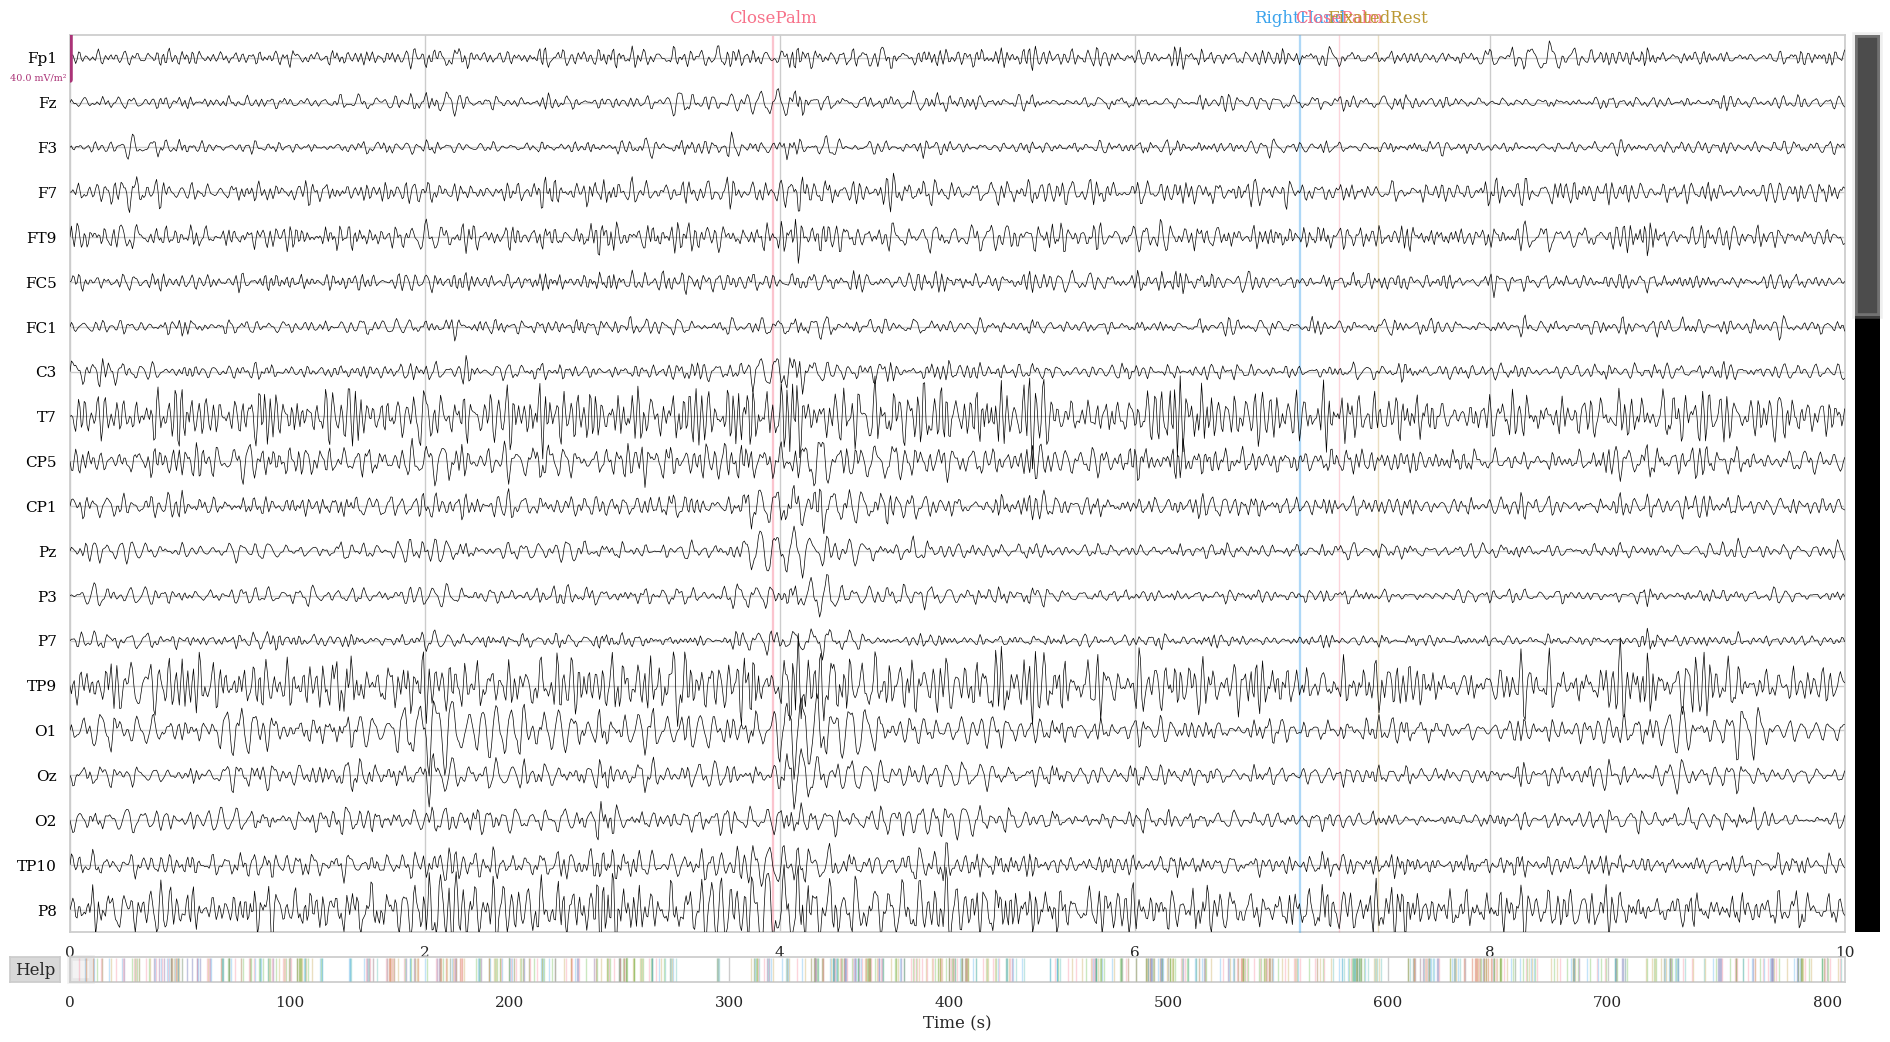

In [33]:
fname = 'NZ_Raw_for_analysis_140526'

path_fname = current_path /'Models'/ fname
#%% Load the selected model

#read the pickle file   
picklefile = open(path_fname, 'rb')
#unpickle the dataframe
Raw_for_analysis = pickle.load(picklefile)
#close file
picklefile.close()#%% Load the selected model
fname = 'NZ_ann_140526'

path_fname = current_path /'Models'/ fname
#%% Load the selected model

#read the pickle file   
picklefile = open(path_fname, 'rb')
#unpickle the dataframe
original_ann = pickle.load(picklefile)
#close file
picklefile.close()#%% Load the selected model

Raw_for_analysis.set_annotations(stream_annotations)
Raw_for_analysis.plot()

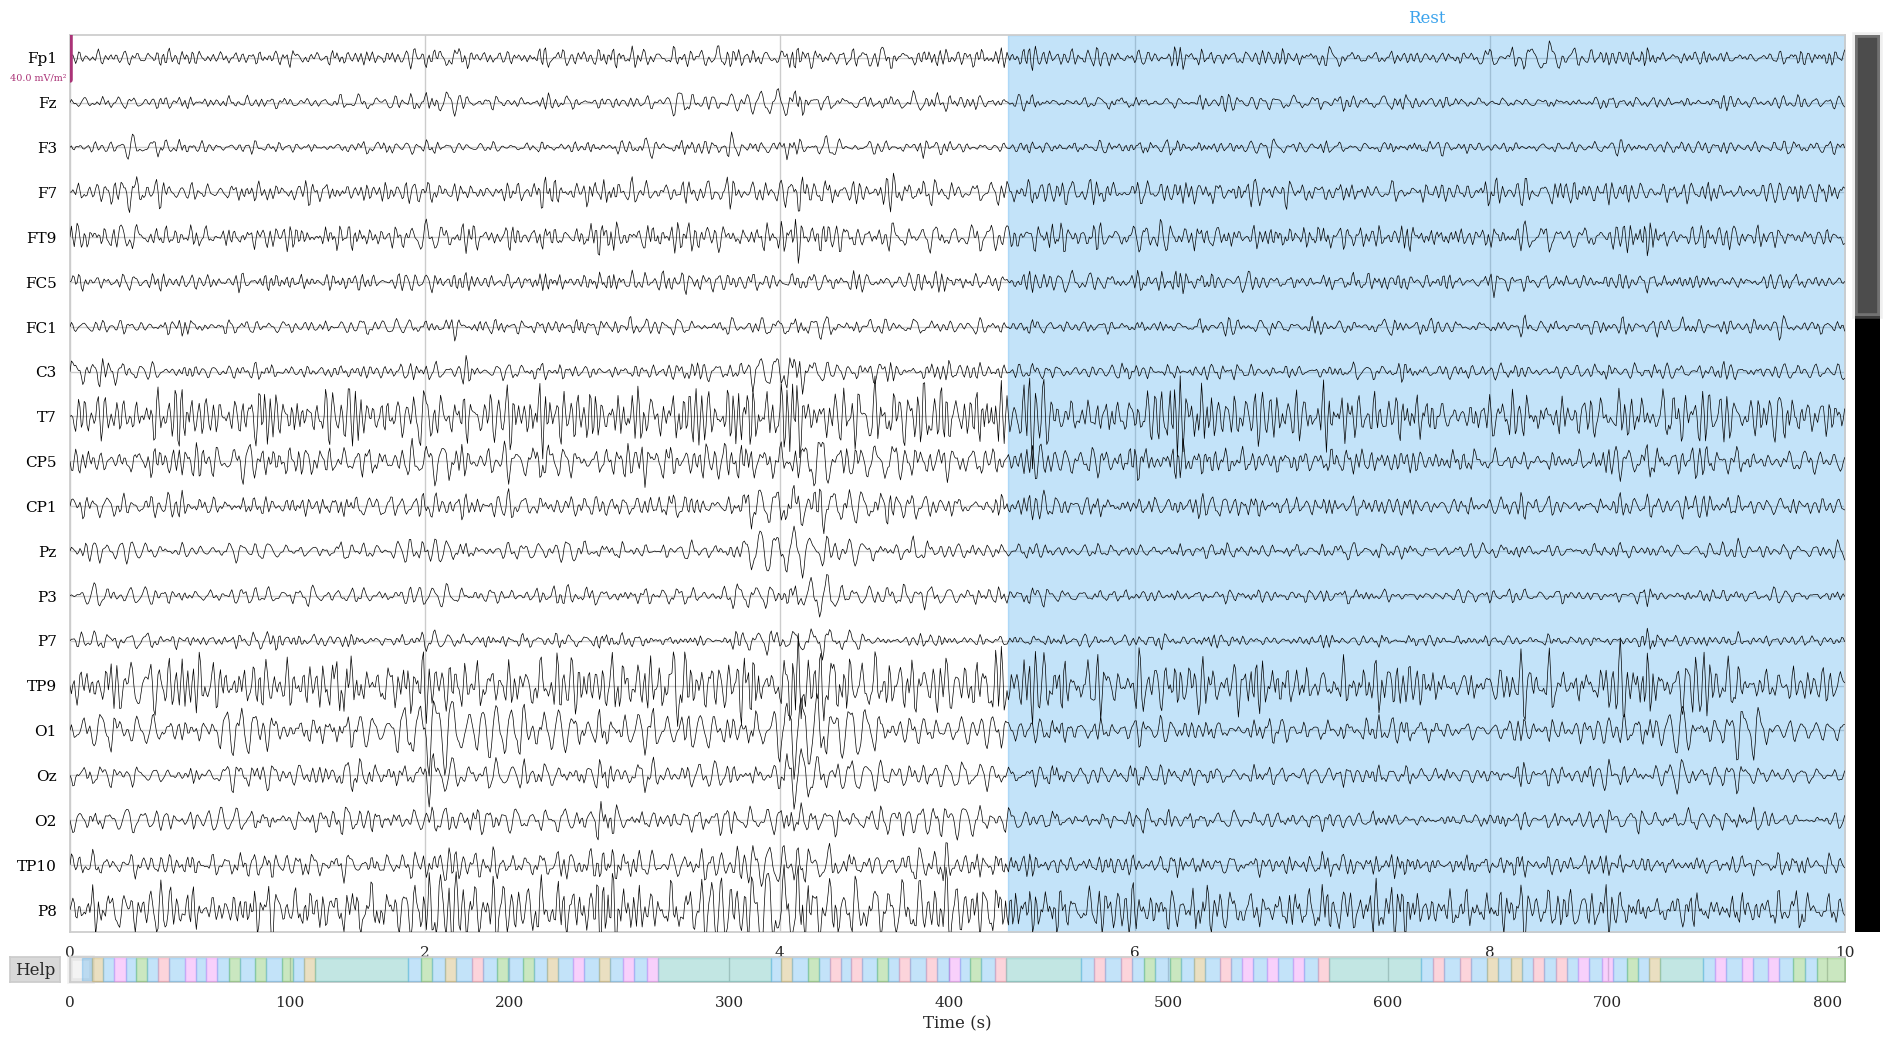

In [34]:
Raw_for_analysis.set_annotations(original_ann)
Raw_for_analysis.plot()

In [35]:
Raw_for_analysis.set_annotations(event_ann)
Raw_for_analysis.plot()

NameError: name 'event_ann' is not defined

In [ ]:
saved_ann1 = ann1

In [72]:

ann1 = stream_annotations
ann2 = original_ann
# Shift all onsets in ann1 back by 2 seconds
ann1_shifted = mne.Annotations(
    onset=ann1.onset - 2.0,       # subtract 2s from each onset
    duration=ann1.duration.copy(),  # keep durations the same
    description=ann1.description.copy(),  # keep labels the same
    orig_time=ann1.orig_time      # preserve original time reference
)

ann_std = relabel_annotations(
    ann1_shifted,
    mapping={"Noise": "FixatedRest"}

)
ann2_std = relabel_annotations(
    ann2,
    mapping={}
)
event_ann_std = expand_triggers_to_events(ann_std,Raw_for_analysis)
event_ann = expand_triggers_to_events(ann1_shifted,Raw_for_analysis)

In [ ]:

def _to_intervals(ann, include_desc=None):
    """Convert event-style annotations to (start, end, desc) tuples."""
    on = np.asarray(ann.onset, float)
    du = np.asarray(ann.duration, float)
    desc = np.asarray(ann.description, dtype=object)
    if include_desc is not None:
        mask = np.isin(desc, list(include_desc))
        on, du, desc = on[mask], du[mask], desc[mask]
    return [(float(s), float(s + d), str(dsc)) for s, d, dsc in zip(on, du, desc)]

def _intersections_by_desc(iv1, iv2):
    """Return {desc: [(start, end), ...]} where intervals overlap AND labels match."""
    by1, by2 = {}, {}
    for s, e, d in iv1: by1.setdefault(d, []).append((s, e))
    for s, e, d in iv2: by2.setdefault(d, []).append((s, e))
    common = set(by1).intersection(by2)
    out = {d: [] for d in common}
    for d in common:
        a = sorted(by1[d]); b = sorted(by2[d])
        i = j = 0
        while i < len(a) and j < len(b):
            s1, e1 = a[i]; s2, e2 = b[j]
            sI, eI = max(s1, s2), min(e1, e2)
            if eI > sI:
                out[d].append((sI, eI))
            if e1 <= e2: i += 1
            else:        j += 1
    return out

def compute_matching_annotations_events(raw, ann1_events, ann2_events, include_desc=None, min_len=0.0):
    """
    Build Annotations with description='match:<desc>' where ann1 & ann2
    have the SAME label and their event intervals overlap.
    """
    iv1 = _to_intervals(ann1_events, include_desc)
    iv2 = _to_intervals(ann2_events, include_desc)
    overlaps = _intersections_by_desc(iv1, iv2)


    on, du, ds = [], [], []
    for d, segs in overlaps.items():
        for s, e in segs:
            if (e - s) >= float(min_len):
                on.append(s); du.append(e - s); ds.append(f"match:{d}")

    if not on:
        return mne.Annotations([], [], [], orig_time=raw.info['meas_date'])
    return mne.Annotations(on, du, ds, orig_time=raw.info['meas_date'])

In [47]:

def _to_intervals(ann, include_desc=None):
    """Return list of (start, end, desc) in seconds (relative to raw)."""
    on = np.asarray(ann.onset, float)
    du = np.asarray(ann.duration, float)
    desc = np.asarray(ann.description, dtype=object)
    if include_desc is not None:
        mask = np.isin(desc, list(include_desc))
        on, du, desc = on[mask], du[mask], desc[mask]
    return [(float(s), float(s + d), str(dsc))          # <-- dsc, not d
            for s, d, dsc in zip(on, du, desc)]

def _intersections_by_desc(iv1, iv2):
    """
    Given two lists of intervals (start,end,desc), return a dict:
    {desc: list of (start,end) overlaps} where desc matches in both lists.
    """
    by1, by2 = {}, {}
    for s,e,d in iv1: by1.setdefault(d, []).append((s,e))
    for s,e,d in iv2: by2.setdefault(d, []).append((s,e))
    common = set(by1).intersection(by2)
    out = {d: [] for d in common}
    for d in common:
        a = sorted(by1[d])
        b = sorted(by2[d])
        i=j=0
        while i < len(a) and j < len(b):
            s1,e1 = a[i]
            s2,e2 = b[j]
            sI = max(s1, s2)
            eI = min(e1, e2)
            if eI > sI:           # there is an overlap
                out[d].append((sI, eI))
            if e1 <= e2: i += 1
            else:        j += 1
    return out
def compute_matching_annotations_from_triggers(raw, ann1, ann2, include_desc=None, min_len=0.0):
    """
    Build an mne.Annotations containing 'match:<desc>' segments where ann1 & ann2
    have the SAME label and their (trigger-expanded) intervals overlap.

    Parameters
    ----------
    raw : mne.io.BaseRaw
    ann1, ann2 : mne.Annotations (trigger streams)
    include_desc : iterable[str] or None
        Only start states from these labels. If None, use all labels.
    min_len : float
        Minimum overlap length to keep (seconds).

    Returns
    -------
    matches : mne.Annotations
    """
    end_time = float(raw.times[-1])

    iv1 = _to_intervals_from_triggers(ann1, end_time, include_desc=include_desc)
    iv2 = _to_intervals_from_triggers(ann2, end_time, include_desc=include_desc)

    overlaps = _intersections_by_desc(iv1, iv2)

    onsets, durations, descs = [], [], []
    for d, segs in overlaps.items():
        for s, e in segs:
            if (e - s) >= float(min_len):
                onsets.append(s)
                durations.append(e - s)
                descs.append(f"match:{d}")

    if not onsets:
        return mne.Annotations([], [], [], orig_time=raw.info['meas_date'])

    return mne.Annotations(onsets, durations, descs, orig_time=raw.info['meas_date'])
def _to_intervals_from_triggers(ann, recording_end, include_desc=None):
    """
    Convert a trigger-style Annotations (point markers) into intervals where
    each trigger's label holds until the next trigger onset.

    Parameters
    ----------
    ann : mne.Annotations
        Trigger annotations (durations may be 0 or tiny).
    recording_end : float
        End time of the recording in seconds (e.g., raw.times[-1]).
    include_desc : iterable[str] or None
        If provided, only triggers with these descriptions will be *kept as states*.
        IMPORTANT: The state lasts until the *next trigger*, regardless of its label.

    Returns
    -------
    intervals : list of (start, end, desc)
        Non-overlapping intervals covering from each trigger onset to the next.
    """
    on = np.asarray(ann.onset, float)
    desc = np.asarray(ann.description, dtype=object)

    # Sort by onset (stable)
    order = np.argsort(on, kind="mergesort")
    on = on[order]
    desc = desc[order]

    # Optionally keep only certain starting triggers
    if include_desc is not None:
        mask = np.isin(desc, list(include_desc))
        on = on[mask]
        desc = desc[mask]

    if len(on) == 0:
        return []

    # Next onset for each trigger; last extends to recording_end
    next_on = np.r_[on[1:], recording_end]

    # Build intervals (clip any non-positive lengths)
    intervals = []
    for s, e, d in zip(on, next_on, desc):
        if e > s:
            intervals.append((float(s), float(e), str(d)))
    return intervals

def compute_matching_annotations(raw, ann1, ann2, include_desc=None, min_len=0.0):
    """
    Return an mne.Annotations with description='match:<desc>' for the overlaps
    where ann1 and ann2 share the SAME description and time overlap.
    
    Parameters
    ----------
    raw : mne.io.BaseRaw
    ann1, ann2 : mne.Annotations
    include_desc : iterable of str or None
        If provided, only these descriptions are compared.
    min_len : float
        Discard overlaps shorter than this (seconds).
    """
    iv1 = _to_intervals(ann1, include_desc)
    iv2 = _to_intervals(ann2, include_desc)
    overlaps = _intersections_by_desc(iv1, iv2)

    onsets, durations, descs = [], [], []
    for d, segs in overlaps.items():
        for s, e in segs:
            if (e - s) >= float(min_len):
                onsets.append(s)
                durations.append(e - s)
                descs.append(f"match:{d}")
    if not onsets:
        return mne.Annotations([], [], [], orig_time=raw.info['meas_date'])

    # Important: make the annotations relative to raw by ensuring orig_time matches
    return mne.Annotations(onsets, durations, descs, orig_time=raw.info['meas_date'])

def plot_raw_with_matches(raw, matches, picks="eeg", tmin=None, tmax=None):
    """
    Plot raw with green shading for matching annotations. We’ll force green
    by using a simple Matplotlib overlay (robust across MNE versions).
    """
    # Get data to plot
    picks = mne.pick_types(raw.info, eeg=True) if picks == "eeg" else mne.pick_channels(raw.ch_names, picks)
    data, times = raw.get_data(picks=picks, start=raw.time_as_index(tmin)[0] if tmin else None,
                               stop=raw.time_as_index(tmax)[0] if tmax else None, return_times=True)
    if tmin is None: tmin = times[0]
    if tmax is None: tmax = times[-1]

    # Simple stacked plot
    fig, ax = plt.subplots(figsize=(12, 6))
    offset = 0.0
    step = np.nanstd(data) * 5 or 1e-6  # spacing between traces
    for k in range(data.shape[0]):
        ax.plot(times, data[k] + offset)
        offset += step
    ax.set_xlim(tmin, tmax)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Channels (stacked)")
    ax.set_title("EEG with matching annotations (green)")

    # Shade matches
    for onset, dur, desc in zip(matches.onset, matches.duration, matches.description):
        start = onset
        end = onset + dur
        if end < tmin or start > tmax:
            continue
        ax.axvspan(max(start, tmin), min(end, tmax), color="green", alpha=0.25)

    plt.tight_layout()
    return fig

# -------------------------
# Example usage:
# -------------------------
# include = {"StimA", "StimB"}  # descriptions you care about
# matches = compute_matching_annotations(raw, ann1, ann2, include_desc=include, min_len=0.05)
# fig = plot_raw_with_matches(raw, matches, picks="eeg", tmin=10.0, tmax=40.0)
# plt.show()


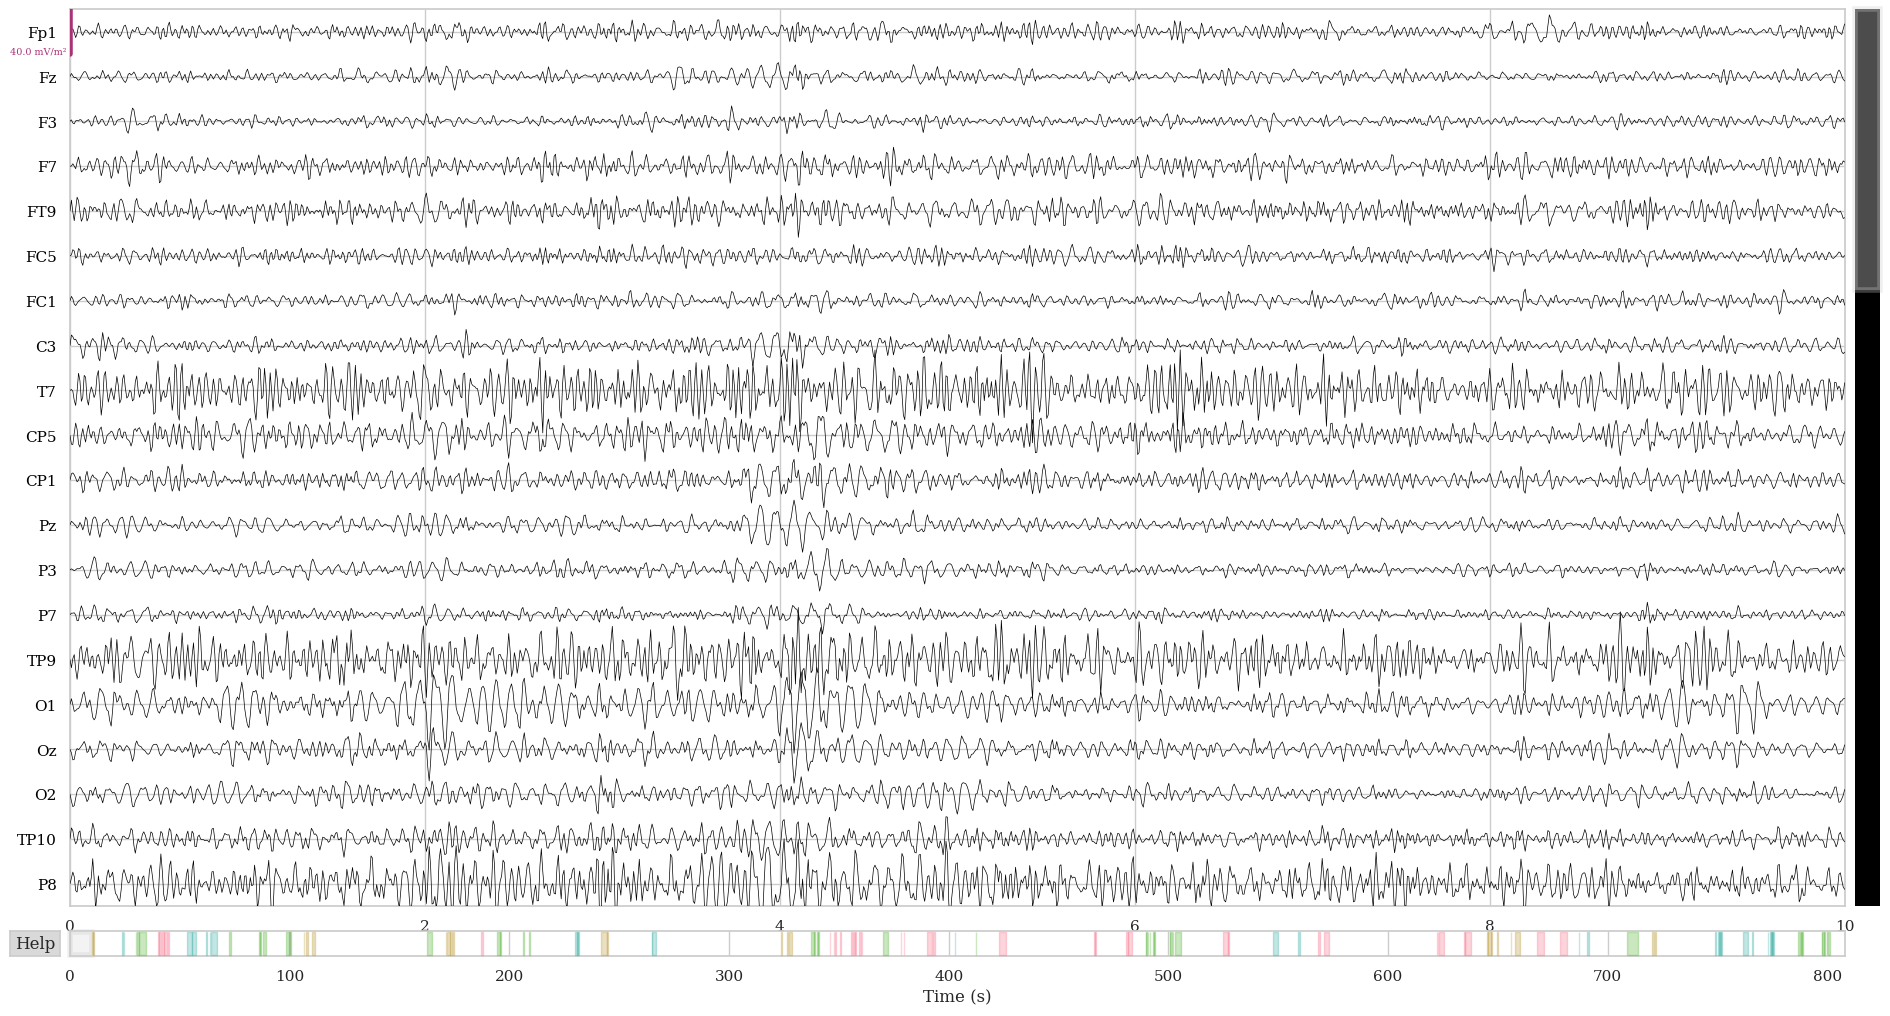

In [48]:
# Choose labels to compare (or set to None to include all)
include = {"FixatedRest", "ClosePalm","RightHand","LeftHand"}  # or None

matches = compute_matching_annotations_events(
    Raw_for_analysis,
    event_ann_std,
    ann2_std,
    include_desc=include,
    min_len=0.02  # ignore overlaps < 20 ms if you want
)

# Option A: plot in MNE browser (auto-shaded)
raw_match = Raw_for_analysis.copy()
raw_match.set_annotations(matches)
raw_match.plot()

# Option B: if you want guaranteed green shading, reuse your custom overlay:
# fig = plot_raw_with_matches(raw, matches, picks="eeg", tmin=10, tmax=40)


In [37]:
import re
import numpy as np
import mne

def relabel_annotations(
    ann,
    mapping=None,               # dict: {'old': 'new', ...}
    regex_map=None,             # list of (pattern, repl)
    func=None,                  # callable(desc) -> new_desc or None (drop)
    drop=None,                  # set/list of labels to remove
    merge_adjacent=True,
    tol=1e-9
):
    """
    Relabel (and optionally drop) annotations, preserving timing and orig_time.

    Parameters
    ----------
    ann : mne.Annotations
    mapping : dict or None
        Exact replacements: {'old': 'new', ...}
    regex_map : list[tuple(str, str)] or None
        Regex replacements applied in order with re.sub.
    func : callable or None
        func(desc) -> new_desc (str) or None to drop this event.
        Applied after mapping/regex_map.
    drop : set/list or None
        Exact labels to drop before func is applied.
    merge_adjacent : bool
        If True, merge back-to-back intervals that share the same label.
    tol : float
        Time tolerance to consider intervals contiguous when merging.

    Returns
    -------
    mne.Annotations
    """
    on = np.asarray(ann.onset, float).copy()
    du = np.asarray(ann.duration, float).copy()
    ds = list(ann.description)

    # 1) Exact mapping
    if mapping:
        ds = [mapping.get(d, d) for d in ds]

    # 2) Regex mapping
    if regex_map:
        compiled = [(re.compile(p), r) for (p, r) in regex_map]
        new_ds = []
        for d in ds:
            dd = d
            for pat, repl in compiled:
                dd = pat.sub(repl, dd)
            new_ds.append(dd)
        ds = new_ds

    # 3) Drop labels
    if drop:
        drop_set = set(drop)
        keep_mask = [d not in drop_set for d in ds]
        on = on[keep_mask]
        du = du[keep_mask]
        ds = [d for d, k in zip(ds, keep_mask) if k]

    # 4) Custom mapper
    if func:
        mapped = []
        keep_idx = []
        for i, d in enumerate(ds):
            out = func(d)
            if out is not None:
                mapped.append(out)
                keep_idx.append(i)
        on = on[keep_idx]
        du = du[keep_idx]
        ds = mapped

    # Early exit if empty
    if len(ds) == 0:
        return mne.Annotations([], [], [], orig_time=ann.orig_time)

    # 5) Sort by onset (stable)
    order = np.argsort(on, kind="mergesort")
    on = on[order]
    du = du[order]
    ds = [ds[i] for i in order]

    # 6) Merge adjacent with same label
    if merge_adjacent and len(ds) > 1:
        mon, mdu, mds = [], [], []
        cur_s = on[0]
        cur_e = on[0] + du[0]
        cur_d = ds[0]
        for s, durr, dsc in zip(on[1:], du[1:], ds[1:]):
            e = s + durr
            if (dsc == cur_d) and (abs(s - cur_e) <= tol):
                cur_e = e  # extend
            else:
                mon.append(cur_s); mdu.append(cur_e - cur_s); mds.append(cur_d)
                cur_s, cur_e, cur_d = s, e, dsc
        # flush last
        mon.append(cur_s); mdu.append(cur_e - cur_s); mds.append(cur_d)
        on = np.array(mon, float)
        du = np.array(mdu, float)
        ds = mds

    return mne.Annotations(on, du, ds, orig_time=ann.orig_time)


In [ ]:
# 1) Compare an annotation object to itself → must produce matches
matches_self = compute_matching_annotations(Raw_for_analysis, ann1, ann1)
print(matches_self)  # should list 'match:<desc>' segments

# 2) Check what descriptions you actually have
print("unique desc ann1:", set(ann1.description))
print("unique desc ann2:", set(ann2.description))


<Annotations | 0 segments>
unique desc ann1: {'ClosePalm', 'Noise', 'ActiveRest', 'Rest'}
unique desc ann2: {'ClosePalm', 'Rating-5', 'Long Break', 'ActiveRest', 'Beep', 'OpenPalm', 'Rest', 'Rating-6', 'Rating-4'}


In [ ]:
import numpy as np
import mne

def _to_intervals(ann, include_desc=None):
    on  = np.asarray(ann.onset, float)
    du  = np.asarray(ann.duration, float)
    ds  = np.asarray(ann.description, dtype=object)
    if include_desc is not None:
        keep = np.isin(ds, list(include_desc))
        on, du, ds = on[keep], du[keep], ds[keep]
    order = np.argsort(on, kind="mergesort")
    on, du, ds = on[order], du[order], ds[order]
    return [(float(s), float(s + dur), str(desc))
            for s, dur, desc in zip(on, du, ds)]

def compare_events_matches_and_negatives(
    raw,
    ann1_events,
    ann2_events,
    include_desc=None,     # None = consider all labels; otherwise subset
    min_len=0.0,           # drop segments shorter than this (sec)
    record_negatives=True, # False => only matches (like your working fn)
    merge_adjacent=True,   # coalesce adjacent identical outputs
    tol=1e-9               # adjacency tolerance for merging
):
    """
    Compare two event-style annotation streams.
    Emits 'match:<L>' when labels agree over an overlap,
    and 'neg:<L1>|<L2>' when they disagree (if record_negatives=True).
    """
    a = _to_intervals(ann1_events, include_desc)
    b = _to_intervals(ann2_events, include_desc)
    if not a or not b:
        return mne.Annotations([], [], [], orig_time=raw.info['meas_date'])

    i = j = 0
    on, du, ds = [], [], []

    while i < len(a) and j < len(b):
        s1, e1, d1 = a[i]
        s2, e2, d2 = b[j]

        # overlap
        sI = max(s1, s2)
        eI = min(e1, e2)

        if eI > sI:
            seg_len = eI - sI
            if seg_len >= float(min_len):
                # If include_desc is used, keep if *either* side is in it (already filtered by _to_intervals)
                if d1 == d2:
                    on.append(sI); du.append(seg_len); ds.append(f"match:{d1}")
                elif record_negatives:
                    on.append(sI); du.append(seg_len); ds.append(f"neg:{d1}|{d2}")

        # advance the interval that ends first
        if e1 <= e2:
            i += 1
        else:
            j += 1

    if not on:
        return mne.Annotations([], [], [], orig_time=raw.info['meas_date'])

    # Optional: merge adjacent with same description
    if merge_adjacent and len(on) > 1:
        order = np.argsort(on, kind="mergesort")
        on = [on[k] for k in order]
        du = [du[k] for k in order]
        ds = [ds[k] for k in order]

        mon, mdu, mds = [], [], []
        cur_s = on[0]; cur_e = on[0] + du[0]; cur_d = ds[0]
        for s, durr, dsc in zip(on[1:], du[1:], ds[1:]):
            e = s + durr
            if dsc == cur_d and abs(s - cur_e) <= tol:
                cur_e = e
            else:
                mon.append(cur_s); mdu.append(cur_e - cur_s); mds.append(cur_d)
                cur_s, cur_e, cur_d = s, e, dsc
        mon.append(cur_s); mdu.append(cur_e - cur_s); mds.append(cur_d)
        on, du, ds = mon, mdu, mds

    return mne.Annotations(on, du, ds, orig_time=raw.info['meas_date'])
# 1) Positives-only (should match your working function)
cmp_pos = compare_events_matches_and_negatives(Raw_for_analysis, event_ann_std, ann2,
                                               include_desc={"ClosePalm", "ActiveRest"}, record_negatives=True)
print(cmp_pos)



<Annotations | 122 segments: match:ActiveRest (35), match:ClosePalm (26), ...>


In [ ]:
import mne

# Assume you already have:
# raw : mne.io.Raw
# ann1, ann2 : mne.Annotations
include = {"ActiveRest", "ClosePalm"}

# Step 1. Compute the overlaps
matches = compute_matching_annotations_from_triggers(
    Raw_for_analysis,
    ann1_shifted,
    ann2,
    include_desc=include,
    min_len=0.02  # ignore overlaps shorter than 20 ms
)

print(matches)   # shows the new "match:..." annotations


NameError: name 'compute_matching_annotations_from_triggers' is not defined

In [ ]:
Raw_for_analysis.set_annotations(cmp_pos)

Raw_for_analysis.plot()

In [41]:

# ---- build overlap segments with (pred_label, true_label) ----
def pair_segments(ann_pred, ann_true, include_desc=None, min_len=0.0):
    A = _to_intervals(ann_pred, include_desc)
    B = _to_intervals(ann_true, include_desc)
    i = j = 0
    segs = []  # (start, end, y_pred, y_true)
    while i < len(A) and j < len(B):
        s1, e1, d1 = A[i]
        s2, e2, d2 = B[j]
        sI = max(s1, s2)
        eI = min(e1, e2)
        if eI > sI:
            if (eI - sI) >= float(min_len):
                segs.append((sI, eI, d1, d2))
        if e1 <= e2:
            i += 1
        else:
            j += 1
    return segs

# ---- duration-weighted confusion + metrics ----
def duration_confusion_and_metrics(ann_pred, ann_true, labels, min_len=0.0):
    """
    labels: ordered list like ['X','Y'] defining matrix axes
    Returns: confusion_df (seconds), metrics dict, and normalized views
    """
    segs = pair_segments(ann_pred, ann_true, include_desc=set(labels), min_len=min_len)
    # init matrix of durations
    idx = {lab:k for k,lab in enumerate(labels)}
    M = np.zeros((len(labels), len(labels)), dtype=float)
    total = 0.0
    for s, e, yp, yt in segs:
        w = e - s
        if yp in idx and yt in idx:
            M[idx[yt], idx[yp]] += w  # rows=true, cols=pred
            total += w

    # Avoid div by zero
    eps = 1e-12
    diag = np.diag(M).sum()
    accuracy = diag / (total + eps)

    # Per-class recall (TP/actual true), precision (TP/predicted), F1
    true_sums = M.sum(axis=1)   # rows
    pred_sums = M.sum(axis=0)   # cols
    TP = np.diag(M)
    recall = (TP / (true_sums + eps))
    precision = (TP / (pred_sums + eps))
    f1 = (2 * precision * recall) / (precision + recall + eps)

    # Macro / weighted
    support = true_sums
    macro = dict(
        precision=float(np.mean(precision)),
        recall=float(np.mean(recall)),
        f1=float(np.mean(f1))
    )
    weighted = dict(
        precision=float(np.average(precision, weights=support + eps)),
        recall=float(np.average(recall, weights=support + eps)),
        f1=float(np.average(f1, weights=support + eps))
    )

    # Cohen's kappa (duration-weighted)
    p0 = accuracy
    p_true = true_sums / (total + eps)
    p_pred = pred_sums / (total + eps)
    pe = float((p_true * p_pred).sum())
    kappa = (p0 - pe) / (1 - pe + eps)

    # DataFrames
    confusion_df = pd.DataFrame(M, index=[f"true:{l}" for l in labels],
                                   columns=[f"pred:{l}" for l in labels])

    row_norm = confusion_df.div(confusion_df.sum(axis=1).replace(0, np.nan), axis=0)  # recalls
    col_norm = confusion_df.div(confusion_df.sum(axis=0).replace(0, np.nan), axis=1)  # precisions

    metrics = {
        "total_seconds": float(total),
        "accuracy": float(accuracy),
        "kappa": float(kappa),
        "per_class": {
            lab: {"precision": float(precision[i]),
                  "recall": float(recall[i]),
                  "f1": float(f1[i]),
                  "support_seconds": float(support[i])}
            for i, lab in enumerate(labels)
        },
        "macro": macro,
        "weighted": weighted,
    }
    return confusion_df, row_norm, col_norm, metrics

In [42]:
labels =  ["FixatedRest", "ClosePalm","RightHand","LeftHand"]# order defines the matrix axes
conf, conf_rownorm, conf_colnorm, metrics = duration_confusion_and_metrics(
    ann_pred=event_ann_std,    # predictions
    ann_true=ann2_std,    # ground truth
    labels=labels,
    min_len=0.02             
    # ignore tiny slivers <20 ms (optional)
)

print(conf)          # seconds per (true,row) x (pred,column)
print(conf_rownorm)  # per-true-class recall view
print(conf_colnorm)  # per-pred-class precision view
print(metrics["accuracy"], metrics["kappa"])
print(metrics["per_class"])
print("=== True label durations (seconds) ===")
for lab, info in metrics["per_class"].items():
    print(f"{lab}: {info['support_seconds']:.2f} sec")


                  pred:FixatedRest  pred:ClosePalm  pred:RightHand  \
true:FixatedRest         18.856131       10.340018        4.784099   
true:ClosePalm            6.714503       42.185771       10.225619   
true:RightHand            3.552222       28.692432       22.265518   
true:LeftHand             3.590830       23.972418       15.301765   

                  pred:LeftHand  
true:FixatedRest      15.730724  
true:ClosePalm        15.879279  
true:RightHand        20.689958  
true:LeftHand         36.619217  
                  pred:FixatedRest  pred:ClosePalm  pred:RightHand  \
true:FixatedRest          0.379315        0.208003        0.096238   
true:ClosePalm            0.089521        0.562438        0.136332   
true:RightHand            0.047237        0.381548        0.296084   
true:LeftHand             0.045177        0.301600        0.192513   

                  pred:LeftHand  
true:FixatedRest       0.316444  
true:ClosePalm         0.211709  
true:RightHand         0.2

In [51]:
import numpy as np
import pandas as pd

# Full metrics (all labels)
labels_all = ["FixatedRest", "ClosePalm", "RightHand", "LeftHand"]
conf_all, conf_rownorm_all, conf_colnorm_all, metrics_all = duration_confusion_and_metrics(
    ann_pred=event_ann_std,
    ann_true=ann2_std,
    labels=labels_all,
    min_len=0.02
)

print("="*60)
print("FULL CONFUSION MATRIX (all labels)")
print("="*60)
print(f"Overall Accuracy: {metrics_all['accuracy']:.3f}")
print(f"Cohen's Kappa: {metrics_all['kappa']:.3f}")

# Convert to numpy if needed
conf_np = np.array(conf_all) if not isinstance(conf_all, np.ndarray) else conf_all
conf_rownorm_np = np.array(conf_rownorm_all) if not isinstance(conf_rownorm_all, np.ndarray) else conf_rownorm_all

# Filter: keep rows 1,2,3 (exclude row 0 = FixatedRest), keep all columns
labels_true_no_rest = ["ClosePalm", "RightHand", "LeftHand"]
labels_pred_all = ["FixatedRest", "ClosePalm", "RightHand", "LeftHand"]

# Extract rows 1,2,3 (indices for non-Rest true labels)
conf_filtered = conf_np[1:, :]  # All rows except first (FixatedRest)
conf_rownorm_filtered = conf_rownorm_np[1:, :]

print("\n" + "="*60)
print("CONFUSION MATRIX - Motor Imagery Tasks Only (TRUE)")
print("Including Rest predictions to see misclassifications")
print("="*60)
print("\nAbsolute durations (seconds):")
print(f"{'':15s}", end='')
for pred_lab in labels_pred_all:
    print(f"{pred_lab:>15s}", end='')
print()
for i, true_lab in enumerate(labels_true_no_rest):
    print(f"{true_lab:15s}", end='')
    for j in range(len(labels_pred_all)):
        print(f"{conf_filtered[i, j]:15.2f}", end='')
    print()

print("\n" + "="*60)
print("ROW-NORMALIZED (Recall - where did true MI tasks go?)")
print("="*60)
print(f"{'':15s}", end='')
for pred_lab in labels_pred_all:
    print(f"{pred_lab:>15s}", end='')
print()
for i, true_lab in enumerate(labels_true_no_rest):
    print(f"{true_lab:15s}", end='')
    for j in range(len(labels_pred_all)):
        print(f"{conf_rownorm_filtered[i, j]:15.3f}", end='')
    print()

# Calculate accuracy for motor imagery tasks only
mi_correct = sum(conf_filtered[i, i+1] for i in range(len(labels_true_no_rest)))  # +1 because FixatedRest is col 0
mi_total = conf_filtered.sum()
mi_accuracy = mi_correct / mi_total if mi_total > 0 else 0

# Calculate how often Rest was incorrectly predicted during MI tasks
rest_predictions_during_mi = conf_filtered[:, 0].sum()  # Column 0 = FixatedRest
rest_prediction_rate = rest_predictions_during_mi / mi_total if mi_total > 0 else 0

print("\n" + "="*60)
print("MOTOR IMAGERY METRICS (excluding Rest from ground truth)")
print("="*60)
print(f"Accuracy (MI tasks only): {mi_accuracy:.3f}")
print(f"Total MI task duration: {mi_total:.2f} sec")
print(f"\nRest incorrectly predicted during MI: {rest_predictions_during_mi:.2f} sec ({rest_prediction_rate*100:.1f}%)")
print(f"Non-Rest correctly classified: {mi_correct:.2f} sec ({mi_accuracy*100:.1f}%)")

# Per-class breakdown
print("\nPer-class breakdown (MI tasks):")
for i, true_lab in enumerate(labels_true_no_rest):
    row_total = conf_filtered[i, :].sum()
    correct_duration = conf_filtered[i, i+1]  # +1 offset for diagonal
    rest_pred = conf_filtered[i, 0]  # Column 0 = FixatedRest
    
    print(f"\n{true_lab}:")
    print(f"  Total duration: {row_total:.2f} sec")
    print(f"  Correctly predicted: {correct_duration:.2f} sec ({correct_duration/row_total*100:.1f}%)")
    print(f"  Predicted as Rest: {rest_pred:.2f} sec ({rest_pred/row_total*100:.1f}%)")
    
    # Show other misclassifications
    for j, pred_lab in enumerate(labels_pred_all):
        if j != (i+1) and j != 0:  # Not diagonal, not Rest
            if conf_filtered[i, j] > 0:
                print(f"  Predicted as {pred_lab}: {conf_filtered[i, j]:.2f} sec ({conf_filtered[i, j]/row_total*100:.1f}%)")


FULL CONFUSION MATRIX (all labels)
Overall Accuracy: 0.429
Cohen's Kappa: 0.225

CONFUSION MATRIX - Motor Imagery Tasks Only (TRUE)
Including Rest predictions to see misclassifications

Absolute durations (seconds):
                   FixatedRest      ClosePalm      RightHand       LeftHand
ClosePalm                 6.71          42.19          10.23          15.88
RightHand                 3.55          28.69          22.27          20.69
LeftHand                  3.59          23.97          15.30          36.62

ROW-NORMALIZED (Recall - where did true MI tasks go?)
                   FixatedRest      ClosePalm      RightHand       LeftHand
ClosePalm                0.090          0.562          0.136          0.212
RightHand                0.047          0.382          0.296          0.275
LeftHand                 0.045          0.302          0.193          0.461

MOTOR IMAGERY METRICS (excluding Rest from ground truth)
Accuracy (MI tasks only): 0.440
Total MI task duration: 229.69 

In [44]:
import numpy as np
import pandas as pd

# Full metrics (all labels)
labels_all = ["FixatedRest", "ClosePalm", "RightHand", "LeftHand"]
conf_all, conf_rownorm_all, conf_colnorm_all, metrics_all = duration_confusion_and_metrics(
    ann_pred=event_ann_std,
    ann_true=ann2_std,
    labels=labels_all,
    min_len=0.02
)

print("="*80)
print("FULL CONFUSION MATRIX (ALL LABELS INCLUDING REST)")
print("="*80)
print(f"Overall Accuracy: {metrics_all['accuracy']:.3f}")
print(f"Cohen's Kappa: {metrics_all['kappa']:.3f}")

# Convert to numpy if needed
conf_np = np.array(conf_all) if not isinstance(conf_all, np.ndarray) else conf_all
conf_rownorm_np = np.array(conf_rownorm_all) if not isinstance(conf_rownorm_all, np.ndarray) else conf_rownorm_all
conf_colnorm_np = np.array(conf_colnorm_all) if not isinstance(conf_colnorm_all, np.ndarray) else conf_colnorm_all

# Display full confusion matrix
print("\nAbsolute durations (seconds):")
print(f"{'':15s}", end='')
for pred_lab in labels_all:
    print(f"{pred_lab:>15s}", end='')
print()
for i, true_lab in enumerate(labels_all):
    print(f"{true_lab:15s}", end='')
    for j in range(len(labels_all)):
        print(f"{conf_np[i, j]:15.2f}", end='')
    print()

print("\nRow-normalized (Recall):")
print(f"{'':15s}", end='')
for pred_lab in labels_all:
    print(f"{pred_lab:>15s}", end='')
print()
for i, true_lab in enumerate(labels_all):
    print(f"{true_lab:15s}", end='')
    for j in range(len(labels_all)):
        print(f"{conf_rownorm_np[i, j]:15.3f}", end='')
    print()

# Full stats breakdown (all labels)
print("\n" + "="*80)
print("PER-CLASS STATS (ALL LABELS)")
print("="*80)
for i, true_lab in enumerate(labels_all):
    row_total = conf_np[i, :].sum()
    correct = conf_np[i, i]
    
    print(f"\n{true_lab}:")
    print(f"  Total duration: {row_total:.2f} sec")
    print(f"  Correctly predicted: {correct:.2f} sec ({correct/row_total*100:.1f}%)")
    print(f"  Misclassifications:")
    for j, pred_lab in enumerate(labels_all):
        if i != j and conf_np[i, j] > 0.01:  # Show misclassifications > 0.01 sec
            print(f"    → {pred_lab}: {conf_np[i, j]:.2f} sec ({conf_np[i, j]/row_total*100:.1f}%)")

# Now filter for Motor Imagery only
print("\n\n" + "="*80)
print("MOTOR IMAGERY ONLY (TRUE LABELS = MI TASKS, PREDICTIONS = ALL)")
print("="*80)

labels_true_no_rest = ["ClosePalm", "RightHand", "LeftHand"]

# Extract rows 1,2,3 (indices for non-Rest true labels), keep all columns
conf_filtered = conf_np[1:, :]
conf_rownorm_filtered = conf_rownorm_np[1:, :]

print("\nAbsolute durations (seconds):")
print(f"{'':15s}", end='')
for pred_lab in labels_all:
    print(f"{pred_lab:>15s}", end='')
print()
for i, true_lab in enumerate(labels_true_no_rest):
    print(f"{true_lab:15s}", end='')
    for j in range(len(labels_all)):
        print(f"{conf_filtered[i, j]:15.2f}", end='')
    print()

print("\nRow-normalized (Recall - where did true MI tasks go?):")
print(f"{'':15s}", end='')
for pred_lab in labels_all:
    print(f"{pred_lab:>15s}", end='')
print()
for i, true_lab in enumerate(labels_true_no_rest):
    print(f"{true_lab:15s}", end='')
    for j in range(len(labels_all)):
        print(f"{conf_rownorm_filtered[i, j]:15.3f}", end='')
    print()

# Calculate MI-only accuracy
mi_correct = sum(conf_filtered[i, i+1] for i in range(len(labels_true_no_rest)))  # +1 because FixatedRest is col 0
mi_total = conf_filtered.sum()
mi_accuracy = mi_correct / mi_total if mi_total > 0 else 0

# Calculate how often Rest was incorrectly predicted during MI tasks
rest_predictions_during_mi = conf_filtered[:, 0].sum()  # Column 0 = FixatedRest
rest_prediction_rate = rest_predictions_during_mi / mi_total if mi_total > 0 else 0

print("\n" + "="*80)
print("MOTOR IMAGERY METRICS SUMMARY")
print("="*80)
print(f"Accuracy (MI tasks only): {mi_accuracy:.3f} ({mi_accuracy*100:.1f}%)")
print(f"Total MI task duration: {mi_total:.2f} sec")
print(f"Correctly classified MI: {mi_correct:.2f} sec ({mi_accuracy*100:.1f}%)")
print(f"\nMisclassification Analysis:")
print(f"  Rest incorrectly predicted: {rest_predictions_during_mi:.2f} sec ({rest_prediction_rate*100:.1f}%)")

# Calculate confusion between MI classes
mi_confused = mi_total - mi_correct - rest_predictions_during_mi
mi_confused_rate = mi_confused / mi_total if mi_total > 0 else 0
print(f"  Confused between MI classes: {mi_confused:.2f} sec ({mi_confused_rate*100:.1f}%)")

# Per-MI-class breakdown
print("\n" + "="*80)
print("DETAILED BREAKDOWN BY MI CLASS")
print("="*80)
for i, true_lab in enumerate(labels_true_no_rest):
    row_total = conf_filtered[i, :].sum()
    correct_duration = conf_filtered[i, i+1]  # +1 offset for diagonal
    rest_pred = conf_filtered[i, 0]  # Column 0 = FixatedRest
    
    print(f"\n{true_lab} (Total: {row_total:.2f} sec):")
    print(f"  ✓ Correctly predicted: {correct_duration:.2f} sec ({correct_duration/row_total*100:.1f}%)")
    print(f"  ✗ Predicted as Rest: {rest_pred:.2f} sec ({rest_pred/row_total*100:.1f}%)")
    
    # Show confusions with other MI classes
    print(f"  ✗ Confused with other MI:")
    for j, pred_lab in enumerate(labels_all):
        if j != (i+1) and j != 0:  # Not diagonal, not Rest
            if conf_filtered[i, j] > 0.01:
                print(f"      → {pred_lab}: {conf_filtered[i, j]:.2f} sec ({conf_filtered[i, j]/row_total*100:.1f}%)")

# Summary comparison
print("\n" + "="*80)
print("OVERALL SUMMARY")
print("="*80)
print(f"Full accuracy (all classes):        {metrics_all['accuracy']:.3f} ({metrics_all['accuracy']*100:.1f}%)")
print(f"MI-only accuracy (excluding Rest):  {mi_accuracy:.3f} ({mi_accuracy*100:.1f}%)")
print(f"Cohen's Kappa (all classes):        {metrics_all['kappa']:.3f}")
print(f"\nTotal recording duration: {conf_np.sum():.2f} sec")
print(f"  Rest duration: {conf_np[0, :].sum():.2f} sec ({conf_np[0, :].sum()/conf_np.sum()*100:.1f}%)")
print(f"  MI tasks duration: {mi_total:.2f} sec ({mi_total/conf_np.sum()*100:.1f}%)")


FULL CONFUSION MATRIX (ALL LABELS INCLUDING REST)
Overall Accuracy: 0.429
Cohen's Kappa: 0.225

Absolute durations (seconds):
                   FixatedRest      ClosePalm      RightHand       LeftHand
FixatedRest              18.86          10.34           4.78          15.73
ClosePalm                 6.71          42.19          10.23          15.88
RightHand                 3.55          28.69          22.27          20.69
LeftHand                  3.59          23.97          15.30          36.62

Row-normalized (Recall):
                   FixatedRest      ClosePalm      RightHand       LeftHand
FixatedRest              0.379          0.208          0.096          0.316
ClosePalm                0.090          0.562          0.136          0.212
RightHand                0.047          0.382          0.296          0.275
LeftHand                 0.045          0.302          0.193          0.461

PER-CLASS STATS (ALL LABELS)

FixatedRest:
  Total duration: 49.71 sec
  Correctly pred

In [53]:
def window_annotations(ann, t_start, t_end):
    """
    Clip each annotation to the sub-window [t_start, t_end] seconds from its onset.
    Annotations too short to reach t_start are dropped entirely.
    """
    new_onsets, new_durations, new_descriptions = [], [], []
    for onset, duration, description in zip(ann.onset, ann.duration, ann.description):
        # Skip trials that don't reach the window start
        if duration <= t_start:
            continue
        new_onset = onset + t_start
        new_duration = min(duration - t_start, t_end - t_start)
        if new_duration > 0:
            new_onsets.append(new_onset)
            new_durations.append(new_duration)
            new_descriptions.append(description)
    return mne.Annotations(
        onset=new_onsets,
        duration=new_durations,
        description=new_descriptions,
        orig_time=ann.orig_time,
    )
# Zoom into seconds 1–3 of each trial
t_start, t_end = 1.0, 3.0
ann_pred_windowed = window_annotations(event_ann_std, t_start, t_end)
ann_true_windowed = window_annotations(ann2_std, t_start, t_end)

labels_all = ["FixatedRest", "ClosePalm", "RightHand", "LeftHand"]
conf_all, conf_rownorm_all, conf_colnorm_all, metrics_all = duration_confusion_and_metrics(
    ann_pred=ann_pred_windowed,
    ann_true=ann_true_windowed,
    labels=labels_all,
    min_len=0.02
)

In [75]:
import seaborn as sns

t_start, t_end = 0, 5
window_label = f"{t_start}–{t_end}s"

# Only window the ground truth — predictions stay as-is
# pair_segments will clip predictions to the windowed ground-truth intervals
ann_true_windowed = window_annotations(ann2_std, t_start, t_end)

labels_all = ["FixatedRest", "ClosePalm", "RightHand", "LeftHand"]
conf_all, conf_rownorm_all, conf_colnorm_all, metrics_all = duration_confusion_and_metrics(
    ann_pred=event_ann_std,       # <-- original, unwindowed
    ann_true=ann_true_windowed,   # <-- windowed ground truth only
    labels=labels_all,
    min_len=0.02
)
conf_np         = np.array(conf_all)
conf_rownorm_np = np.array(conf_rownorm_all)

# ── metrics ────────────────────────────────────────────────────────────────
conf_mi    = conf_np[1:, :]
mi_total   = conf_mi.sum()
mi_correct = sum(conf_mi[i, i + 1] for i in range(len(labels_mi)))
mi_accuracy = mi_correct / mi_total if mi_total > 0 else 0
rest_during_mi = conf_mi[:, 0].sum()

print(f"Window {window_label}  |  Overall acc: {metrics_all['accuracy']:.3f}  |  "
      f"MI-only acc: {mi_accuracy:.3f}  |  Kappa: {metrics_all['kappa']:.3f}")
print(f"Rest mis-pred during MI: {rest_during_mi:.2f}s ({rest_during_mi/mi_total*100:.1f}%)")

# ── figure: two confusion matrices side by side ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Duration Confusion — window {window_label}", fontsize=13)

conf_rownorm_safe = np.nan_to_num(np.array(conf_rownorm_all), nan=0.0)

for ax, data, title, fmt_str in [
    (axes[0], conf_np,          "Absolute duration (s)",    ".1f"),
    (axes[1], conf_rownorm_safe, "Row-normalised (Recall)", ".2f"),
]:
    vmax = np.nanmax(data) if data.size > 0 else 1.0
    sns.heatmap(data, annot=False, cmap="Blues", vmin=0, vmax=vmax,
                xticklabels=labels_all, yticklabels=labels_all,
                ax=ax, linewidths=0.5)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val = data[i, j]
            text = f"{val:{fmt_str}}" if not np.isnan(val) else "—"
            color = "white" if (val / vmax > 0.6) else "black"
            ax.text(j + 0.5, i + 0.5, text,
                    ha="center", va="center",
                    color=color, fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()


Window 0–5s  |  Overall acc: 0.437  |  MI-only acc: 0.447  |  Kappa: 0.237
Rest mis-pred during MI: 12.77s (5.7%)


In [73]:
def trim_annotations_to_duration(ann, max_duration=3.0):
    """
    Trim each annotation to a maximum duration.
    
    Parameters:
    -----------
    ann : mne.Annotations
        Original annotations
    max_duration : float
        Maximum duration in seconds for each annotation
        
    Returns:
    --------
    mne.Annotations
        Trimmed annotations
    """
    import mne
    
    trimmed_onsets = []
    trimmed_durations = []
    trimmed_descriptions = []
    
    for onset, duration, description in zip(ann.onset, ann.duration, ann.description):
        # Trim duration to max_duration
        new_duration = min(duration, max_duration)
        
        # Only include if there's still some duration left
        if new_duration > 0:
            trimmed_onsets.append(onset)
            trimmed_durations.append(new_duration)
            trimmed_descriptions.append(description)
    
    # Create new annotations with trimmed durations
    trimmed_ann = mne.Annotations(
        onset=trimmed_onsets,
        duration=trimmed_durations,
        description=trimmed_descriptions,
        orig_time=ann.orig_time
    )
    
    return trimmed_ann

# Trim both prediction and ground truth annotations to first 3 seconds
ann_pred_trimmed = trim_annotations_to_duration(event_ann_std, max_duration=3.0)
ann_true_trimmed = trim_annotations_to_duration(ann2_std, max_duration=3.0)

# Now run the analysis on trimmed data
labels_all = ["FixatedRest", "ClosePalm", "RightHand", "LeftHand"]
conf_all, conf_rownorm_all, conf_colnorm_all, metrics_all = duration_confusion_and_metrics(
    ann_pred=ann_pred_trimmed,    # Use trimmed predictions
    ann_true=ann_true_trimmed,    # Use trimmed ground truth
    labels=labels_all,
    min_len=0.02
)

print("="*80)
print("ANALYSIS: FIRST 3 SECONDS OF EACH TRIAL ONLY")
print("="*80)
print(f"Overall Accuracy: {metrics_all['accuracy']:.3f}")
print(f"Cohen's Kappa: {metrics_all['kappa']:.3f}")

# Convert to numpy
conf_np = np.array(conf_all) if not isinstance(conf_all, np.ndarray) else conf_all
conf_rownorm_np = np.array(conf_rownorm_all) if not isinstance(conf_rownorm_all, np.ndarray) else conf_rownorm_all

# Display full confusion matrix
print("\nFull Confusion Matrix - Absolute durations (seconds):")
print(f"{'':15s}", end='')
for pred_lab in labels_all:
    print(f"{pred_lab:>15s}", end='')
print()
for i, true_lab in enumerate(labels_all):
    print(f"{true_lab:15s}", end='')
    for j in range(len(labels_all)):
        print(f"{conf_np[i, j]:15.2f}", end='')
    print()

print("\nRow-normalized (Recall):")
print(f"{'':15s}", end='')
for pred_lab in labels_all:
    print(f"{pred_lab:>15s}", end='')
print()
for i, true_lab in enumerate(labels_all):
    print(f"{true_lab:15s}", end='')
    for j in range(len(labels_all)):
        print(f"{conf_rownorm_np[i, j]:15.3f}", end='')
    print()

# Motor Imagery only (first 3 seconds)
print("\n" + "="*80)
print("MOTOR IMAGERY ONLY - FIRST 3 SECONDS")
print("="*80)

labels_true_no_rest = ["ClosePalm", "RightHand", "LeftHand"]
conf_filtered = conf_np[1:, :]
conf_rownorm_filtered = conf_rownorm_np[1:, :]

print("\nAbsolute durations (seconds):")
print(f"{'':15s}", end='')
for pred_lab in labels_all:
    print(f"{pred_lab:>15s}", end='')
print()
for i, true_lab in enumerate(labels_true_no_rest):
    print(f"{true_lab:15s}", end='')
    for j in range(len(labels_all)):
        print(f"{conf_filtered[i, j]:15.2f}", end='')
    print()

# Calculate MI-only accuracy
mi_correct = sum(conf_filtered[i, i+1] for i in range(len(labels_true_no_rest)))
mi_total = conf_filtered.sum()
mi_accuracy = mi_correct / mi_total if mi_total > 0 else 0
rest_predictions_during_mi = conf_filtered[:, 0].sum()

print("\n" + "="*80)
print("SUMMARY - FIRST 3 SECONDS OF EACH TRIAL")
print("="*80)
print(f"Full accuracy (all classes):       {metrics_all['accuracy']:.3f} ({metrics_all['accuracy']*100:.1f}%)")
print(f"MI-only accuracy (excluding Rest): {mi_accuracy:.3f} ({mi_accuracy*100:.1f}%)")
print(f"Total MI duration analyzed: {mi_total:.2f} sec")
print(f"Rest incorrectly predicted during MI: {rest_predictions_during_mi:.2f} sec ({rest_predictions_during_mi/mi_total*100:.1f}%)")

print("\nPer-class breakdown (first 3 sec):")
for i, true_lab in enumerate(labels_true_no_rest):
    row_total = conf_filtered[i, :].sum()
    correct = conf_filtered[i, i+1]
    rest_pred = conf_filtered[i, 0]
    print(f"\n{true_lab}:")
    print(f"  Total: {row_total:.2f} sec")
    print(f"  Correct: {correct:.2f} sec ({correct/row_total*100:.1f}%)")
    print(f"  As Rest: {rest_pred:.2f} sec ({rest_pred/row_total*100:.1f}%)")


ANALYSIS: FIRST 3 SECONDS OF EACH TRIAL ONLY
Overall Accuracy: 0.457
Cohen's Kappa: 0.263

Full Confusion Matrix - Absolute durations (seconds):
                   FixatedRest      ClosePalm      RightHand       LeftHand
FixatedRest              11.50           5.49           3.71           9.31
ClosePalm                 2.14          27.47           7.36           7.82
RightHand                 1.43          17.71          15.76           9.75
LeftHand                  1.36          10.54          11.63          19.46

Row-normalized (Recall):
                   FixatedRest      ClosePalm      RightHand       LeftHand
FixatedRest              0.383          0.183          0.124          0.310
ClosePalm                0.048          0.613          0.164          0.174
RightHand                0.032          0.397          0.353          0.218
LeftHand                 0.032          0.245          0.270          0.453

MOTOR IMAGERY ONLY - FIRST 3 SECONDS

Absolute durations (seconds):


In [56]:
# First, let's inspect the confusion matrix structure
print("Confusion matrix type:", type(conf_all))
print("\nConfusion matrix:")
print(conf_all)
print("\nIndex (rows):", conf_all.index.tolist() if hasattr(conf_all, 'index') else "Not a DataFrame")
print("Columns:", conf_all.columns.tolist() if hasattr(conf_all, 'columns') else "Not a DataFrame")


Confusion matrix type: <class 'pandas.core.frame.DataFrame'>

Confusion matrix:
                  pred:FixatedRest  pred:ClosePalm  pred:RightHand  \
true:FixatedRest        159.129727       42.945245       65.786164   
true:ClosePalm            6.520088       40.801714        7.175774   
true:RightHand           15.934619        8.282232       35.559107   
true:LeftHand            24.555566       11.004958        4.903971   

                  pred:LeftHand  
true:FixatedRest      80.648050  
true:ClosePalm        20.635929  
true:RightHand        15.367911  
true:LeftHand         57.478110  

Index (rows): ['true:FixatedRest', 'true:ClosePalm', 'true:RightHand', 'true:LeftHand']
Columns: ['pred:FixatedRest', 'pred:ClosePalm', 'pred:RightHand', 'pred:LeftHand']


In [50]:

def true_label_durations(ann_true, labels=None, min_len=0.0):
    # Convert to (start, end, label) and sum by label
    on  = np.asarray(ann_true.onset, float)
    du  = np.asarray(ann_true.duration, float)
    ds  = np.asarray(ann_true.description, dtype=object)

    # keep only desired labels
    if labels is not None:
        keep = np.isin(ds, list(labels))
        on, du, ds = on[keep], du[keep], ds[keep]

    # drop tiny/zero-length segments if desired
    keep = du >= float(min_len)
    on, du, ds = on[keep], du[keep], ds[keep]

    # sum durations per label
    totals = {}
    for lab in (labels if labels is not None else np.unique(ds)):
        totals[str(lab)] = float(np.sum(du[ds == lab])) if np.any(ds == lab) else 0.0

    overall = float(np.sum(list(totals.values())))
    return totals, overall
print("=== True Predicted label durations (seconds) ===")
for lab, info in metrics["per_class"].items():
    print(f"{lab}: {info['support_seconds']:.2f} sec")

# Usage:
labels = ['ActiveRest', 'ClosePalm']  # or None for all labels
totals_true, total_true_all = true_label_durations(ann_true=event_ann2, labels=labels)
print("=== True label durations (seconds) — from ann_true only ===")
for lab in labels:
    secs = totals_true.get(lab, 0.0)
    pct = (secs / total_true_all * 100.0) if total_true_all > 0 else 0.0
    print(f"{lab}: {secs:.2f} sec ({pct:.1f}%)")
print(f"Total (true): {total_true_all:.2f} sec")

=== True Predicted label durations (seconds) ===
FixatedRest: 348.51 sec
ClosePalm: 75.13 sec
RightHand: 75.14 sec
LeftHand: 97.94 sec


NameError: name 'event_ann2' is not defined

In [61]:
# Overlap (prediction-evaluated) durations
print("=== True Predicted label durations (seconds, overlap only) ===")
overlap_total = 0.0
for lab, info in metrics["per_class"].items():
    secs = info['support_seconds']
    overlap_total += secs
    print(f"{lab}: {secs:.2f} sec")
print(f"Total overlap: {overlap_total:.2f} sec")

# Full ground-truth durations
labels = ['ActiveRest', 'ClosePalm']  # your label set
totals_true, total_true_all = true_label_durations(ann_true=event_ann2, labels=labels)

print("\n=== True label durations (seconds, ann_true total) ===")
for lab in labels:
    secs = totals_true.get(lab, 0.0)
    pct = (secs / total_true_all * 100.0) if total_true_all > 0 else 0.0
    print(f"{lab}: {secs:.2f} sec ({pct:.1f}%)")
print(f"Total (true all): {total_true_all:.2f} sec")

# Accuracy as coverage
accuracy_vs_truth = overlap_total / total_true_all if total_true_all > 0 else float('nan')
print(f"\nCoverage accuracy (overlap / total truth): {accuracy_vs_truth:.3f}")


=== True Predicted label durations (seconds, overlap only) ===
FixatedRest: 348.51 sec
ClosePalm: 75.13 sec
RightHand: 75.14 sec
LeftHand: 97.94 sec
Total overlap: 596.73 sec


NameError: name 'event_ann2' is not defined

In [62]:
print("=== Confusion Matrix (seconds) ===")
print(conf)

print("\n=== Per-class metrics ===")
for lab, info in metrics["per_class"].items():
    print(f"{lab}: "
          f"support={info['support_seconds']:.2f}s, "
          f"precision={info['precision']:.2f}, "
          f"recall={info['recall']:.2f}, "
          f"f1={info['f1']:.2f}")

print("\n=== Overall metrics ===")
print(f"Accuracy (overall)   : {metrics['accuracy']:.3f}")
print(f"Cohen's kappa        : {metrics['kappa']:.3f}")
print(f"Macro-averaged F1    : {metrics['macro']['f1']:.3f}")
print(f"Weighted-averaged F1 : {metrics['weighted']['f1']:.3f}")


=== Confusion Matrix (seconds) ===
                  pred:FixatedRest  pred:ClosePalm  pred:RightHand  \
true:FixatedRest        159.129727       42.945245       65.786164   
true:ClosePalm            6.520088       40.801714        7.175774   
true:RightHand           15.934619        8.282232       35.559107   
true:LeftHand            24.555566       11.004958        4.903971   

                  pred:LeftHand  
true:FixatedRest      80.648050  
true:ClosePalm        20.635929  
true:RightHand        15.367911  
true:LeftHand         57.478110  

=== Per-class metrics ===
FixatedRest: support=348.51s, precision=0.77, recall=0.46, f1=0.57
ClosePalm: support=75.13s, precision=0.40, recall=0.54, f1=0.46
RightHand: support=75.14s, precision=0.31, recall=0.47, f1=0.38
LeftHand: support=97.94s, precision=0.33, recall=0.59, f1=0.42

=== Overall metrics ===
Accuracy (overall)   : 0.491
Cohen's kappa        : 0.278
Macro-averaged F1    : 0.458
Weighted-averaged F1 : 0.510


In [ ]:
# Plot with MNE browser (auto-shaded)
raw_match = Raw_for_analysis.copy()
raw_match.set_annotations(matches)

Measurement date,Unknown
Experimenter,Unknown
Participant,Unknown
Digitized points,68 points
Good channels,34 Current source density
Bad channels,None
EOG channels,Not available
ECG channels,Not available
Sampling frequency,500.00 Hz
Highpass,8.00 Hz
Lowpass,35.00 Hz


In [ ]:
raw_match.plot()